In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import uproot3 as uproot
import pandas as pd
import numpy as np
import math
from tqdm import tqdm
import scipy.optimize
from scipy.linalg import cholesky
from numpy.linalg import inv
from numpy.linalg import pinv

from scipy.stats import norm
from scipy import stats
from scipy.optimize import curve_fit

import statistics

import random

from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

print(uproot.__version__)
print(pd.__version__)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
3.14.4
2.2.2


In [2]:
def get_bin_centers(x):
    centers = []
    for i in range(len(x)-1): centers.append( x[i] + (x[i+1]-x[i])/2 )
    return centers

def get_x_err_Enu(x, x_bins):
    x_err = np.zeros_like([x,x])
    for i in range(len(x)):
            x_err[0][i] = x[i] - x_bins[i]
            x_err[1][i] = x_bins[i+1] - x[i]
    return x_err

In [3]:
slope=18.936

def gaus(x,a,x0,sigma, offset):
    return a*np.exp(-(x-x0)**2/(2*sigma**2)) + offset

def triple_gaus(x,a,x0,sigma, offset):
    return a* ( np.exp(-(x-x0-slope)**2/(2*sigma**2)) + np.exp(-(x-x0)**2/(2*sigma**2)) + np.exp(-(x-x0+slope)**2/(2*sigma**2)) ) + offset

def five_gaus(x,a,x0,sigma, offset):
    return a* ( np.exp(-(x-x0-slope-slope)**2/(2*sigma**2)) + np.exp(-(x-x0-slope)**2/(2*sigma**2)) + np.exp(-(x-x0)**2/(2*sigma**2)) + np.exp(-(x-x0+slope)**2/(2*sigma**2)) + np.exp(-(x-x0+slope+slope)**2/(2*sigma**2)) ) + offset

def gaus_noC(x,a,x0,sigma):
    return a*np.exp(-(x-x0)**2/(2*sigma**2))

def gaus_sum(x,a_1,x0_1,sigma_1,a_2,sigma_2):
    return a_1*np.exp(-(x-x0_1)**2/(2*sigma_1**2))+a_2*np.exp(-(x-x0_1)**2/(2*sigma_2**2))

In [4]:
sel_query = "numu_cc_flag>=0 and numu_score > 0.9"
NC_query = "cosmict_flag==0 and numu_score < 0"
#NC_query = "numu_score < 0"
CCpi0_query = sel_query + ' and (( kine_pio_vtx_dis < 9 ) and kine_pio_energy_1 > 40 and kine_pio_energy_2 > 25 and kine_pio_dis_1 < 110 and kine_pio_dis_2 < 120 and kine_pio_angle > 0 and kine_pio_angle < 174  and kine_pio_mass > 22 and kine_pio_mass < 300)'
#NC pi0 cut based selection
NCpi0_query = NC_query + ' and ((kine_pio_vtx_dis < 9 ) and kine_pio_energy_1 > 40 and kine_pio_energy_2 > 25 and kine_pio_dis_1 < 110 and kine_pio_dis_2 < 120 and kine_pio_angle > 0 and kine_pio_angle < 174  and kine_pio_mass > 22 and kine_pio_mass < 300)'
#CC+NC pi0 cut based selection
pi0_query = '((kine_pio_vtx_dis < 9 ) and kine_pio_energy_1 > 40 and kine_pio_energy_2 > 25 and kine_pio_dis_1 < 110 and kine_pio_dis_2 < 120 and kine_pio_angle > 0 and kine_pio_angle < 174  and kine_pio_mass > 22 and kine_pio_mass < 300)'


In [5]:
more_pf_vars = ["reco_startMomentum","reco_endMomentum","reco_startXYZT","reco_endXYZT","reco_mother","reco_pdg","reco_id"]

kine_vars_data = ["kine_particle_type", "kine_energy_particle", "kine_reco_add_energy", "kine_energy_info",
                 "kine_pio_mass",
                    "kine_pio_flag",
                    "kine_pio_vtx_dis",
                    "kine_pio_energy_1",
                    "kine_pio_theta_1",
                    "kine_pio_phi_1",
                    "kine_pio_dis_1",
                    "kine_pio_energy_2",
                    "kine_pio_theta_2",
                    "kine_pio_phi_2",
                    "kine_pio_dis_2",
                    "kine_pio_angle"]

In [6]:
file = uproot.open("../data/validation_MCC9.10/10_04_07_05/hyper/SURPRISE_Test_Samples_v10_04_07_05_Run4b_hyper_unified_reco2_NuMI_nu_overlay_may8_reco2_hist_62280486_snapshot.root") 
ns_times_df = file["wcpselection"]["T_PFeval"].pandas.df(more_pf_vars+['reco_showerKE',"reco_sps_id","reco_sps_pdg","reco_sps_x","reco_sps_y","reco_sps_z","RWM_Time","PMT_TimeProp","PMT_Amp","PMT_Time","PMT_ID","evtTimeNS",'evtTimeNS_cor',"run","subrun","event",'reco_nuvtxX','reco_nuvtxY','reco_nuvtxZ',"reco_muonMomentum"]+["truth_nu_pos",'truth_nuTime','cor_nu_time','cor_nu_deltatime','cor_nu_time_nospill','cor_nu_time_spill','truth_vtxX','truth_vtxY','truth_vtxZ','mcflux_dk2gen','mcflux_gen2vtx','truth_nuEnergy','truth_nuPdg','truth_isCC','mcflux_genx','mcflux_geny','mcflux_genz','mcflux_vx','mcflux_vy','mcflux_vz'], flatten=False)
eval_df = file["wcpselection"]["T_eval"].pandas.df(["match_isFC",'flash_measPe', 'flash_predPe','truth_vtxInside','weight_cv','weight_spline'], flatten=False)
kine_df = file["wcpselection"]["T_KINEvars"].pandas.df(["kine_reco_Enu"]+kine_vars_data, flatten=False)
bdt_df = file["wcpselection"]["T_BDTvars"].pandas.df(["numu_score","nue_score",'numu_cc_flag','cosmict_flag'], flatten=False)
overlay_df = pd.concat([ns_times_df,eval_df,kine_df,bdt_df], axis=1, sort=False)
overlay_df["rse_num"] = (overlay_df["run"].to_numpy() * 100_000_000_000
                         + overlay_df["subrun"].to_numpy() * 1_000_000
                         + overlay_df["event"].to_numpy())
del kine_df
del ns_times_df
del eval_df
del bdt_df
print(overlay_df.shape[0])
overlay_df = overlay_df.query("kine_reco_Enu>0")
print(overlay_df.shape[0])
overlay_df["net_weight"] = overlay_df["weight_cv"].to_numpy()*overlay_df["weight_spline"].to_numpy()




42806
13237


In [7]:


x = overlay_df['truth_vtxX'].to_numpy()
y = overlay_df['truth_vtxY'].to_numpy()
z = overlay_df['truth_vtxZ'].to_numpy()

times_adjusted = []

for i in range(len(x)):

    #find the correct correction
    dist = z[i]
    new_time_cor = dist*0.033356

        
    times_adjusted.append(new_time_cor)

overlay_df["times_adjusted"] = times_adjusted

In [8]:
gap = 18.83050847457627
Shift = -113.3

ns_time =  overlay_df['cor_nu_time'].to_numpy()-overlay_df["times_adjusted"].to_numpy()

merge_times = []
abs_merge_times = []
for i in range(len(ns_time)):
    
    TThelp = ns_time[i]-Shift+gap*0.5
    TT_merged=-9999

    if TThelp>=0:
        TT_merged=(TThelp-(int((TThelp)/gap))*gap)-gap*0.5
        abs_merge_times.append(abs(TT_merged))
    else: abs_merge_times.append(-999)
        
    merge_times.append(TT_merged)

overlay_df["merge_time_truth"] = merge_times
overlay_df["abs_merge_time_truth"] = abs_merge_times

In [9]:
gap = 18.83050847457627
Shift = -112.7

ns_time =  overlay_df['cor_nu_time_spill'].to_numpy()

merge_times = []
abs_merge_times = []
for i in range(len(ns_time)):
    
    TThelp = ns_time[i]-Shift+gap*0.5
    TT_merged=-9999

    if TThelp>=0:
        TT_merged=(TThelp-(int((TThelp)/gap))*gap)-gap*0.5
        abs_merge_times.append(abs(TT_merged))
    else: abs_merge_times.append(-999)
        
    merge_times.append(TT_merged)

overlay_df["merge_time_truth_spill"] = merge_times
overlay_df["abs_merge_time_truth_spill"] = abs_merge_times

In [10]:
gap = 18.83050847457627
Shift = -113.5

ns_time =  overlay_df['cor_nu_time_nospill'].to_numpy()-overlay_df["times_adjusted"].to_numpy()

merge_times = []
abs_merge_times = []
for i in range(len(ns_time)):
    
    TThelp = ns_time[i]-Shift+gap*0.5
    TT_merged=-9999

    if TThelp>=0:
        TT_merged=(TThelp-(int((TThelp)/gap))*gap)-gap*0.5
        abs_merge_times.append(abs(TT_merged))
    else: abs_merge_times.append(-999)
        
    merge_times.append(TT_merged)

overlay_df["merge_time_truth_nospill"] = merge_times
overlay_df["abs_merge_time_truth_nospill"] = abs_merge_times

In [11]:
run = overlay_df["run"].to_numpy()
evtTimeNS = overlay_df["evtTimeNS_cor"].to_numpy() 

Shift = -109+3.5


new_times = []
abs_new_times = []

for i in range(len(evtTimeNS)):

    TThelp=0
    TThelp = evtTimeNS[i]-Shift+gap*0.5
    TT_merged = -9999.

    if evtTimeNS[i]>0:
        TT_merged=(TThelp-(int((TThelp)/gap))*gap)-gap*0.5        
        new_times.append(TT_merged)
        abs_new_times.append(abs_new_times)
    else:
        new_times.append(-99999)
        abs_new_times.append(-99999)        

overlay_df["merge_time"] = new_times
overlay_df["abs_merge_time"] = abs_new_times

In [12]:
overlay_df['one_bunch_time'] = overlay_df['cor_nu_time'].to_numpy()-overlay_df['times_adjusted'].to_numpy()-np.ones_like(overlay_df['times_adjusted'].to_numpy())*2273-(overlay_df['cor_nu_time_spill'].to_numpy()-overlay_df['merge_time_truth_spill'].to_numpy())


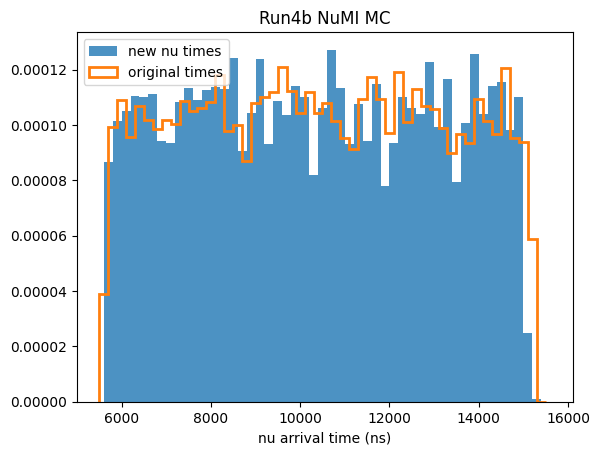

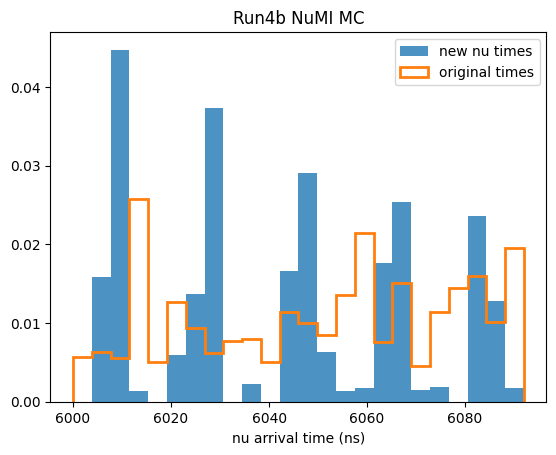

In [18]:
plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(3354+overlay_df["cor_nu_time"].to_numpy()-overlay_df["times_adjusted"].to_numpy(),bins=50,density=True,label='new nu times',range=(5600,5600+10000),alpha=0.8
        ,weights=overlay_df["net_weight"].to_numpy())
plt.hist(overlay_df["truth_nuTime"].to_numpy()*1000,bins=50,density=True,histtype='step',label='original times',range=(5500,5500+10000),lw=2
                ,weights=overlay_df["net_weight"].to_numpy())
plt.xlabel('nu arrival time (ns)')
plt.legend()
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(3354+overlay_df["cor_nu_time"].to_numpy()-overlay_df["times_adjusted"].to_numpy(),bins=24,density=True,label='new nu times',range=(6000,6092),alpha=0.8
                ,weights=overlay_df["net_weight"].to_numpy())
plt.hist(overlay_df["truth_nuTime"].to_numpy()*1000,bins=24,density=True,histtype='step',label='original times',range=(6000,6092),lw=2
                ,weights=overlay_df["net_weight"].to_numpy())
plt.xlabel('nu arrival time (ns)')
plt.legend()
plt.show()

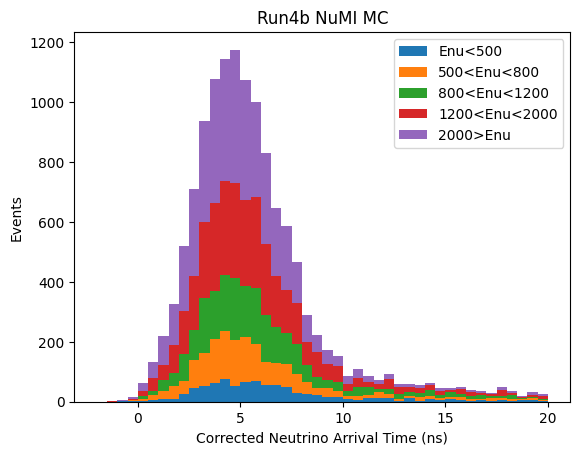

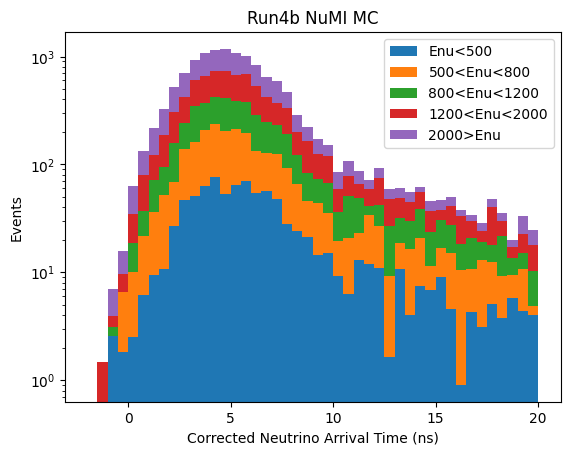

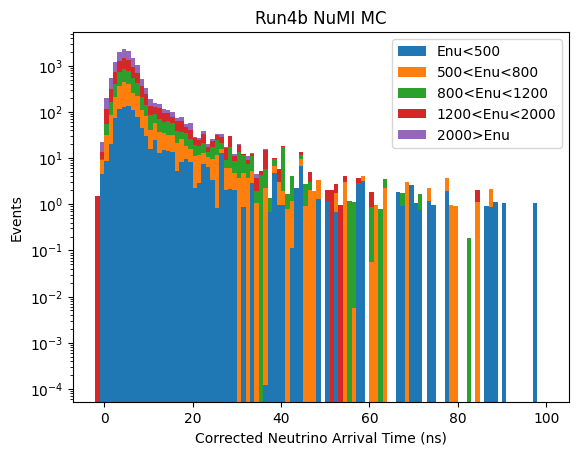

In [22]:
list_of_hist = [
    overlay_df.query("truth_nuEnergy<500")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["one_bunch_time"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("truth_nuEnergy<500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["net_weight"].to_numpy(),
    
]

list_of_labels=[
'Enu<500',
   '500<Enu<800' ,
       '800<Enu<1200' ,
       '1200<Enu<2000' ,
    '2000>Enu'
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=True,label=list_of_labels,range=(-2,20),weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=True,label=list_of_labels,range=(-2,20),weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.yscale('log')
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=102,stacked=True,label=list_of_labels,range=(-2,100),weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.yscale('log')
plt.show()

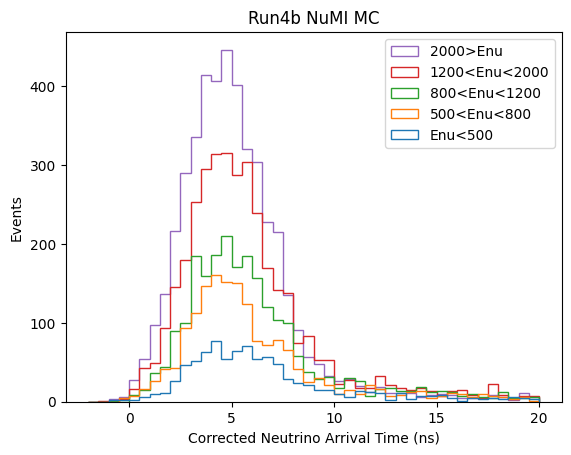

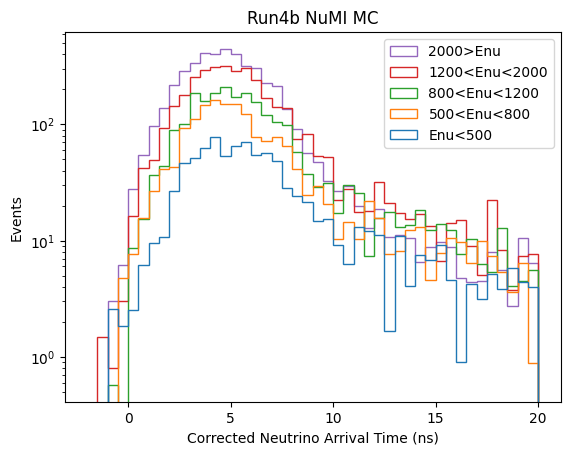

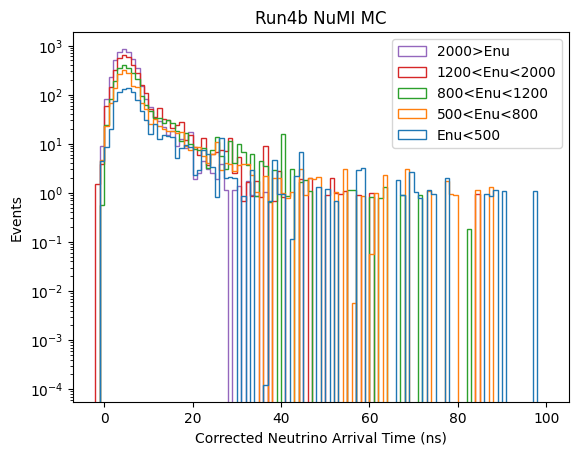

In [23]:
list_of_hist = [
    overlay_df.query("truth_nuEnergy<500")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["one_bunch_time"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("truth_nuEnergy<500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["net_weight"].to_numpy(),
    
]

list_of_labels=[
'Enu<500',
   '500<Enu<800' ,
       '800<Enu<1200' ,
       '1200<Enu<2000' ,
    '2000>Enu'
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=False,label=list_of_labels,range=(-2,20),density=False,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=False,label=list_of_labels,range=(-2,20),density=False,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.yscale('log')
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=102,stacked=False,label=list_of_labels,range=(-2,100),density=False,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.yscale('log')
plt.show()

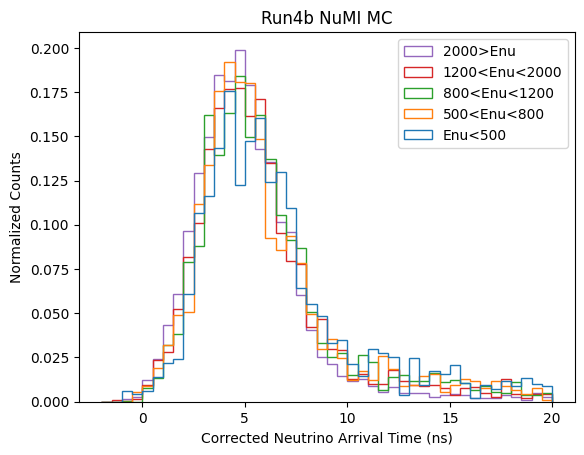

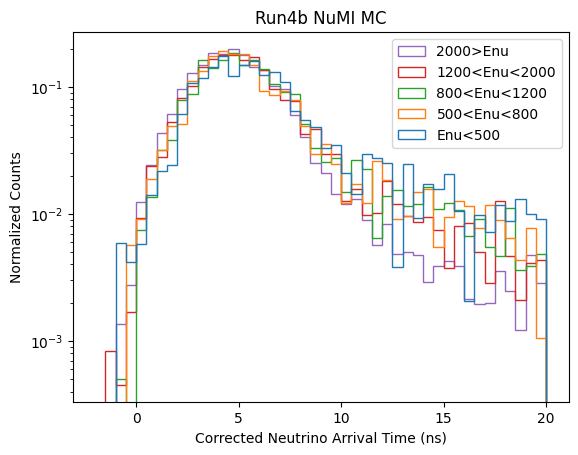

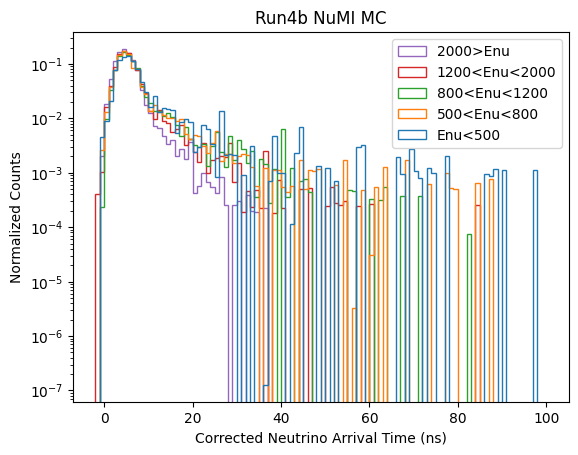

In [24]:
list_of_hist = [
    overlay_df.query("truth_nuEnergy<500")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["one_bunch_time"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("truth_nuEnergy<500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["net_weight"].to_numpy(),
    
]

list_of_labels=[
'Enu<500',
   '500<Enu<800' ,
       '800<Enu<1200' ,
       '1200<Enu<2000' ,
    '2000>Enu'
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=False,label=list_of_labels,range=(-2,20),density=True,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected Neutrino Arrival Time (ns)")
plt.ylabel("Normalized Counts")
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=False,label=list_of_labels,range=(-2,20),density=True,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected Neutrino Arrival Time (ns)")
plt.ylabel("Normalized Counts")
plt.yscale('log')
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=102,stacked=False,label=list_of_labels,range=(-2,100),density=True,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected Neutrino Arrival Time (ns)")
plt.ylabel("Normalized Counts")
plt.yscale('log')
plt.show()

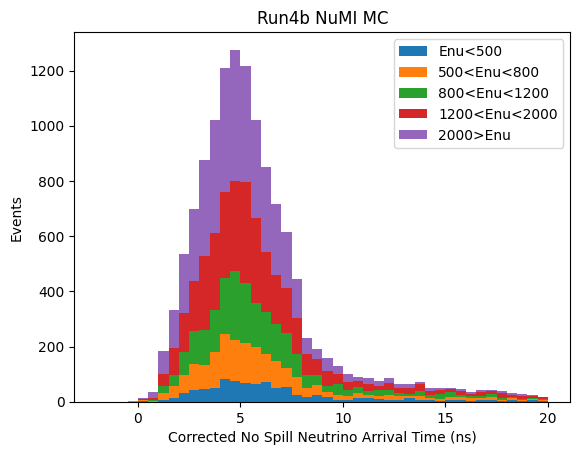

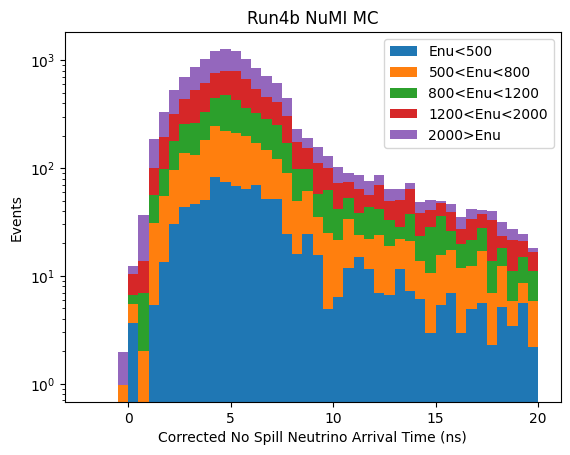

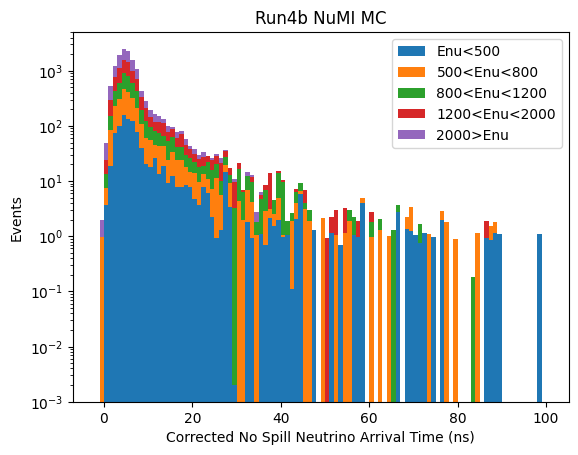

In [25]:
list_of_hist = [
    overlay_df.query("truth_nuEnergy<500")["cor_nu_time_nospill"].to_numpy()-overlay_df.query("truth_nuEnergy<500")["times_adjusted"].to_numpy()-2273,
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["cor_nu_time_nospill"].to_numpy()-overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["times_adjusted"].to_numpy()-2273,
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["cor_nu_time_nospill"].to_numpy()-overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["times_adjusted"].to_numpy()-2273,
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["cor_nu_time_nospill"].to_numpy()-overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["times_adjusted"].to_numpy()-2273,
    overlay_df.query("truth_nuEnergy>2000")["cor_nu_time_nospill"].to_numpy()-overlay_df.query("truth_nuEnergy>2000")["times_adjusted"].to_numpy()-2273,
    
]

list_of_weights = [
    overlay_df.query("truth_nuEnergy<500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["net_weight"].to_numpy(),
    
]

list_of_labels=[
'Enu<500',
   '500<Enu<800' ,
       '800<Enu<1200' ,
       '1200<Enu<2000' ,
    '2000>Enu'
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=True,label=list_of_labels,range=(-2,20),weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=True,label=list_of_labels,range=(-2,20),weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.yscale('log')
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=102,stacked=True,label=list_of_labels,range=(-2,100),weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.yscale('log')
plt.show()

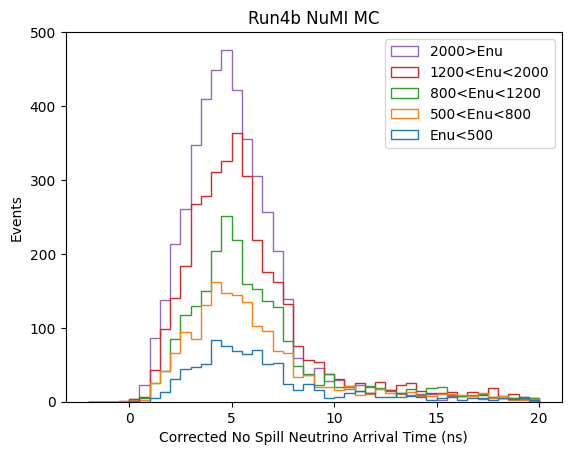

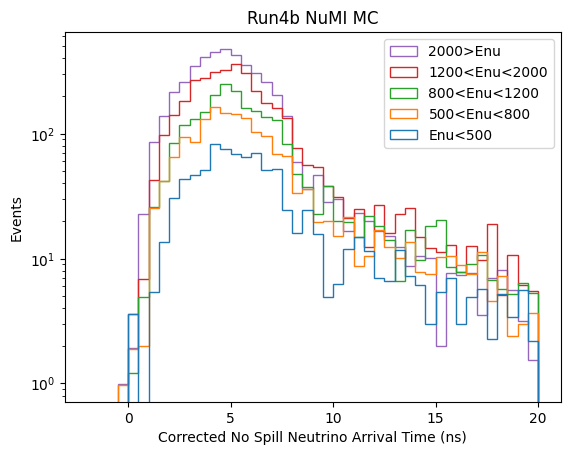

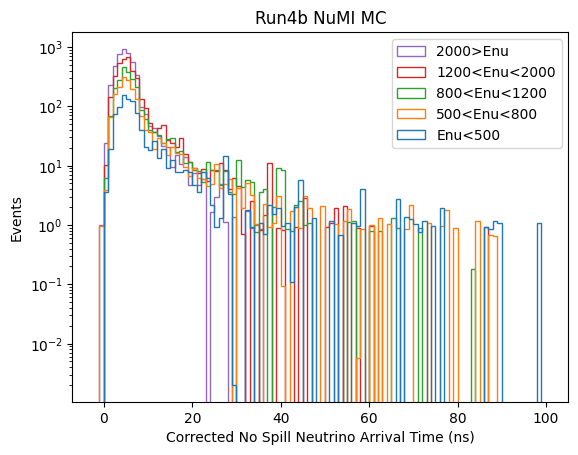

In [26]:
list_of_hist = [
    overlay_df.query("truth_nuEnergy<500")["cor_nu_time_nospill"].to_numpy()-overlay_df.query("truth_nuEnergy<500")["times_adjusted"].to_numpy()-2273,
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["cor_nu_time_nospill"].to_numpy()-overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["times_adjusted"].to_numpy()-2273,
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["cor_nu_time_nospill"].to_numpy()-overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["times_adjusted"].to_numpy()-2273,
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["cor_nu_time_nospill"].to_numpy()-overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["times_adjusted"].to_numpy()-2273,
    overlay_df.query("truth_nuEnergy>2000")["cor_nu_time_nospill"].to_numpy()-overlay_df.query("truth_nuEnergy>2000")["times_adjusted"].to_numpy()-2273,
    
]

list_of_weights = [
    overlay_df.query("truth_nuEnergy<500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["net_weight"].to_numpy(),
    
]


list_of_labels=[
'Enu<500',
   '500<Enu<800' ,
       '800<Enu<1200' ,
       '1200<Enu<2000' ,
    '2000>Enu'
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=False,label=list_of_labels,range=(-2,20),density=False,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=False,label=list_of_labels,range=(-2,20),density=False,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.yscale('log')
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=102,stacked=False,label=list_of_labels,range=(-2,100),density=False,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.yscale('log')
plt.show()

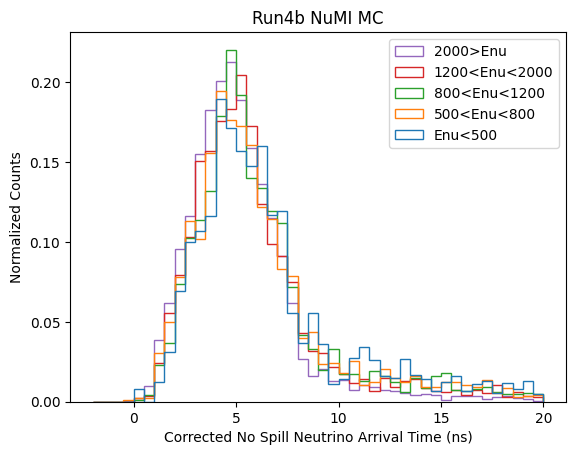

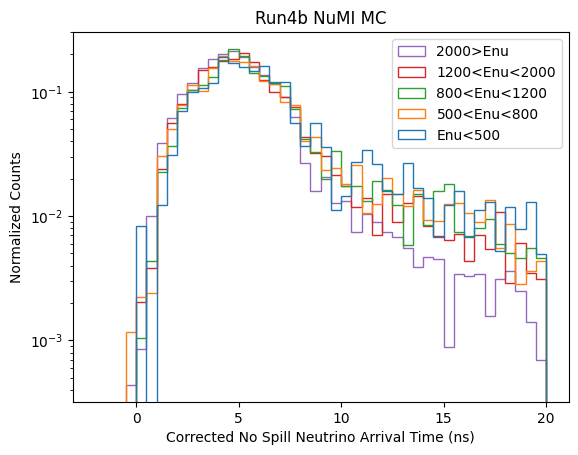

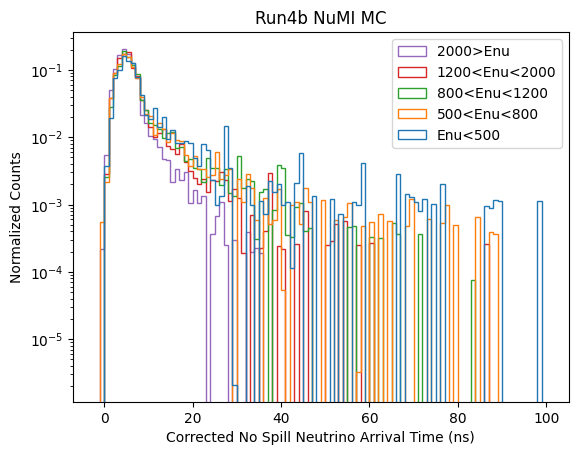

In [27]:
list_of_hist = [
    overlay_df.query("truth_nuEnergy<500")["cor_nu_time_nospill"].to_numpy()-overlay_df.query("truth_nuEnergy<500")["times_adjusted"].to_numpy()-2273,
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["cor_nu_time_nospill"].to_numpy()-overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["times_adjusted"].to_numpy()-2273,
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["cor_nu_time_nospill"].to_numpy()-overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["times_adjusted"].to_numpy()-2273,
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["cor_nu_time_nospill"].to_numpy()-overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["times_adjusted"].to_numpy()-2273,
    overlay_df.query("truth_nuEnergy>2000")["cor_nu_time_nospill"].to_numpy()-overlay_df.query("truth_nuEnergy>2000")["times_adjusted"].to_numpy()-2273,
    
]

list_of_weights = [
    overlay_df.query("truth_nuEnergy<500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["net_weight"].to_numpy(),
    
]


list_of_labels=[
'Enu<500',
   '500<Enu<800' ,
       '800<Enu<1200' ,
       '1200<Enu<2000' ,
    '2000>Enu'
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=False,label=list_of_labels,range=(-2,20),density=True,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.ylabel("Normalized Counts")
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=False,label=list_of_labels,range=(-2,20),density=True,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.ylabel("Normalized Counts")
plt.yscale('log')
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=102,stacked=False,label=list_of_labels,range=(-2,100),density=True,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.ylabel("Normalized Counts")
plt.yscale('log')
plt.show()

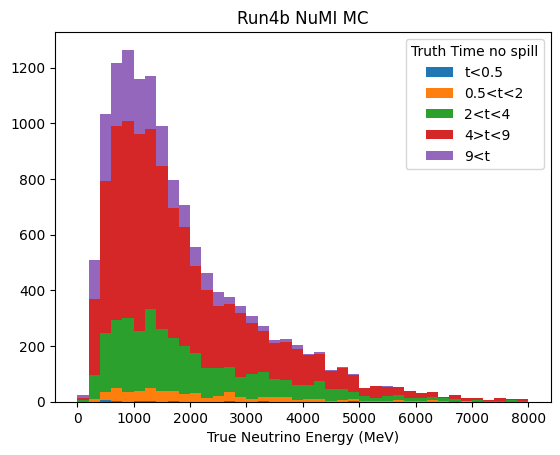

In [28]:
list_of_hist = [
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273<0.5")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273<2 and cor_nu_time_nospill-times_adjusted-2273>0.5")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273<4 and cor_nu_time_nospill-times_adjusted-2273>2")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273<9 and cor_nu_time_nospill-times_adjusted-2273>4")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273>9")["truth_nuEnergy"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273<0.5")["net_weight"].to_numpy(),
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273<2 and cor_nu_time_nospill-times_adjusted-2273>0.5")["net_weight"].to_numpy(),
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273<4 and cor_nu_time_nospill-times_adjusted-2273>2")["net_weight"].to_numpy(),
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273<9 and cor_nu_time_nospill-times_adjusted-2273>4")["net_weight"].to_numpy(),
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273>9")["net_weight"].to_numpy(),
    
]

list_of_labels=[
't<0.5',
       '0.5<t<2' ,
       '2<t<4' ,
    '4>t<9',
       '9<t' ,
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=40,range=(0,8000),stacked=True,label=list_of_labels,weights=list_of_weights)
plt.legend(title='Truth Time no spill')
plt.xlabel('True Neutrino Energy (MeV)')
plt.show()

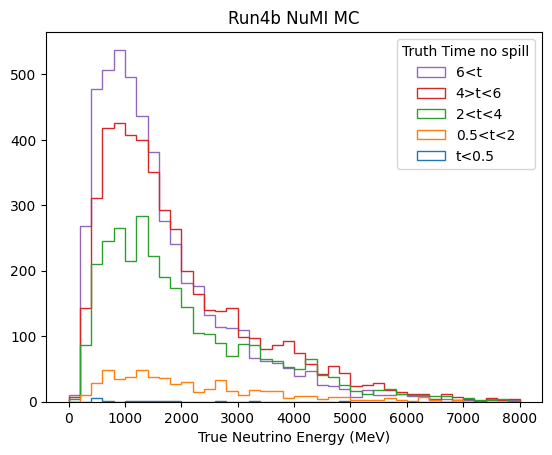

In [31]:
list_of_hist = [
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273<0.5")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273<2 and cor_nu_time_nospill-times_adjusted-2273>0.5")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273<4 and cor_nu_time_nospill-times_adjusted-2273>2")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273<6 and cor_nu_time_nospill-times_adjusted-2273>4")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273>6")["truth_nuEnergy"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273<0.5")["net_weight"].to_numpy(),
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273<2 and cor_nu_time_nospill-times_adjusted-2273>0.5")["net_weight"].to_numpy(),
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273<4 and cor_nu_time_nospill-times_adjusted-2273>2")["net_weight"].to_numpy(),
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273<6 and cor_nu_time_nospill-times_adjusted-2273>4")["net_weight"].to_numpy(),
    overlay_df.query("cor_nu_time_nospill-times_adjusted-2273>6")["net_weight"].to_numpy(),
    
]

list_of_labels=[
't<0.5',
       '0.5<t<2' ,
       '2<t<4' ,
    '4>t<6',
       '6<t' ,
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=40,range=(0,8000),histtype='step',label=list_of_labels,weights=list_of_weights)
plt.legend(title='Truth Time no spill')
plt.xlabel('True Neutrino Energy (MeV)')
plt.show()

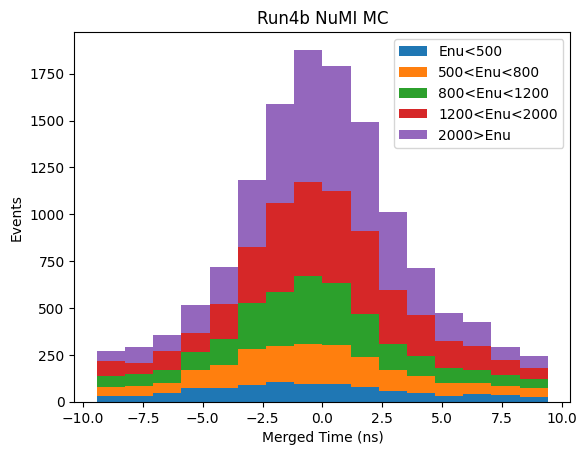

In [32]:
list_of_hist = [
    overlay_df.query("truth_nuEnergy<500")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["merge_time"].to_numpy(),
    
]


list_of_weights = [
    overlay_df.query("truth_nuEnergy<500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["net_weight"].to_numpy(),
    
]

list_of_labels=[
'Enu<500',
   '500<Enu<800' ,
       '800<Enu<1200' ,
       '1200<Enu<2000' ,
    '2000>Enu'
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=16,range=(-9.42,9.42),stacked=True,label=list_of_labels,weights=list_of_weights)
plt.legend()
plt.xlabel("Merged Time (ns)")
plt.ylabel("Events")
plt.show()

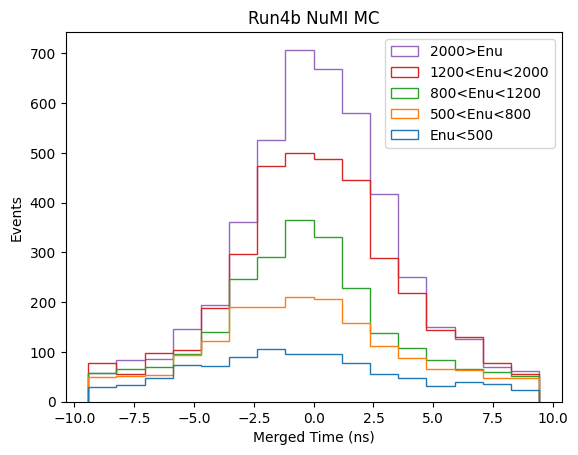

In [33]:
list_of_hist = [
    overlay_df.query("truth_nuEnergy<500")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["merge_time"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("truth_nuEnergy<500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["net_weight"].to_numpy(),
    
]

list_of_labels=[
'Enu<500',
   '500<Enu<800' ,
       '800<Enu<1200' ,
       '1200<Enu<2000' ,
    '2000>Enu'
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=16,range=(-9.42,9.42),stacked=False,label=list_of_labels,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Merged Time (ns)")
plt.ylabel("Events")
plt.show()

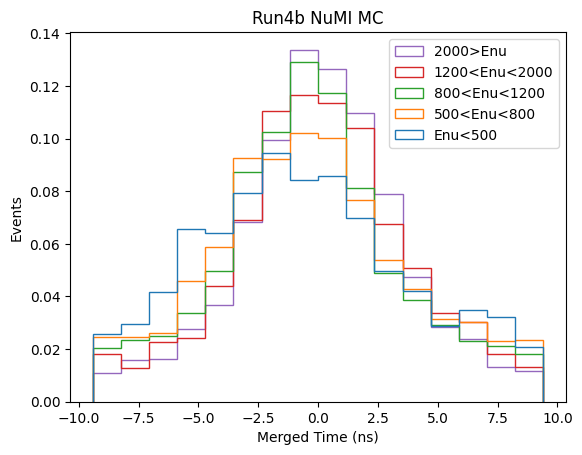

In [34]:
list_of_hist = [
    overlay_df.query("truth_nuEnergy<500")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["merge_time"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("truth_nuEnergy<500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["net_weight"].to_numpy(),
    
]


list_of_labels=[
'Enu<500',
   '500<Enu<800' ,
       '800<Enu<1200' ,
       '1200<Enu<2000' ,
    '2000>Enu'
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=16,range=(-9.42,9.42),stacked=False,label=list_of_labels,histtype='step',density=True,weights=list_of_weights)
plt.legend()
plt.xlabel("Merged Time (ns)")
plt.ylabel("Events")
plt.show()

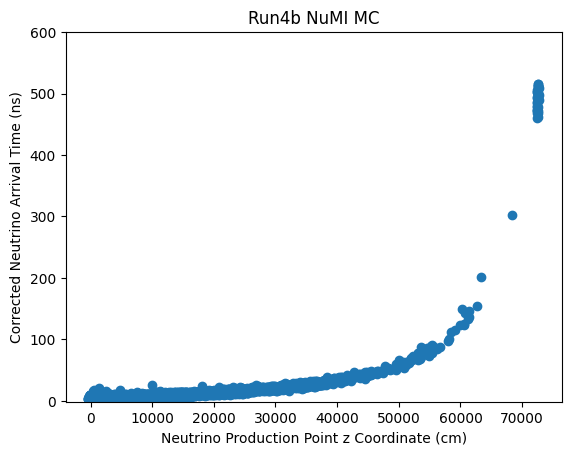

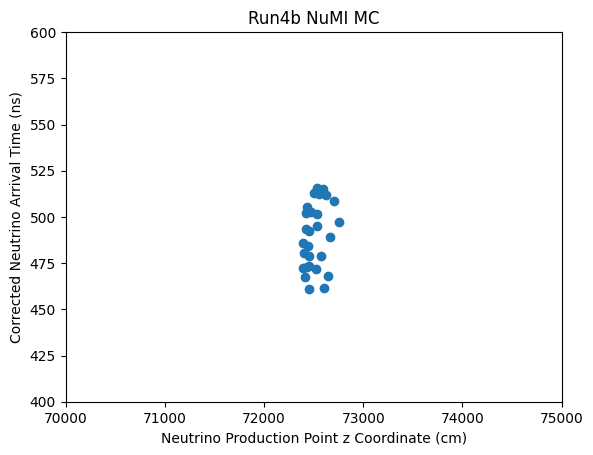

In [36]:

plt.figure()
plt.title("Run4b NuMI MC")
plt.scatter(overlay_df['mcflux_vz'],overlay_df['one_bunch_time'].to_numpy())
plt.ylim(np.min(overlay_df['one_bunch_time'].to_numpy()),600)
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected Neutrino Arrival Time (ns)")
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.scatter(overlay_df['mcflux_vz'],overlay_df['one_bunch_time'].to_numpy())
plt.xlim(70000,75000)
plt.ylim(400,600)
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected Neutrino Arrival Time (ns)")
plt.show()


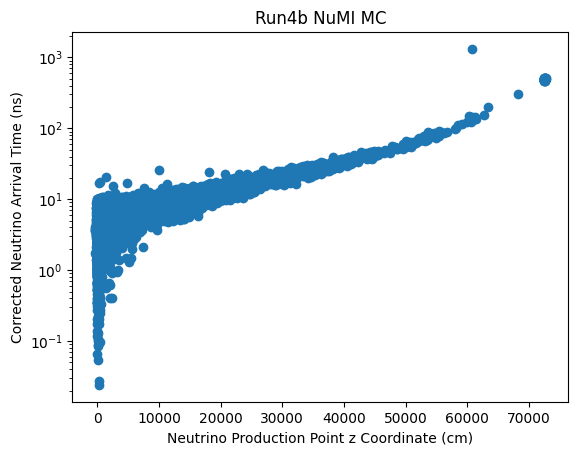

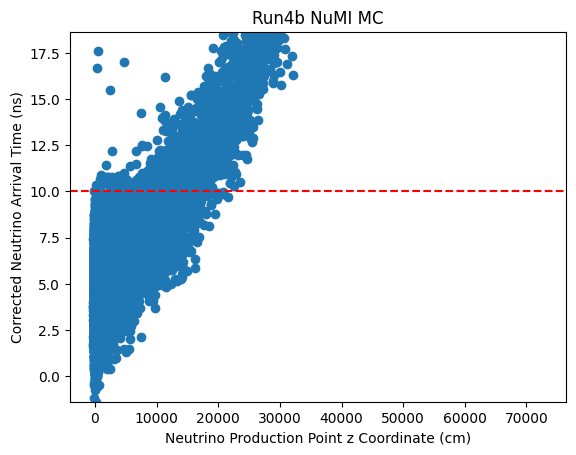

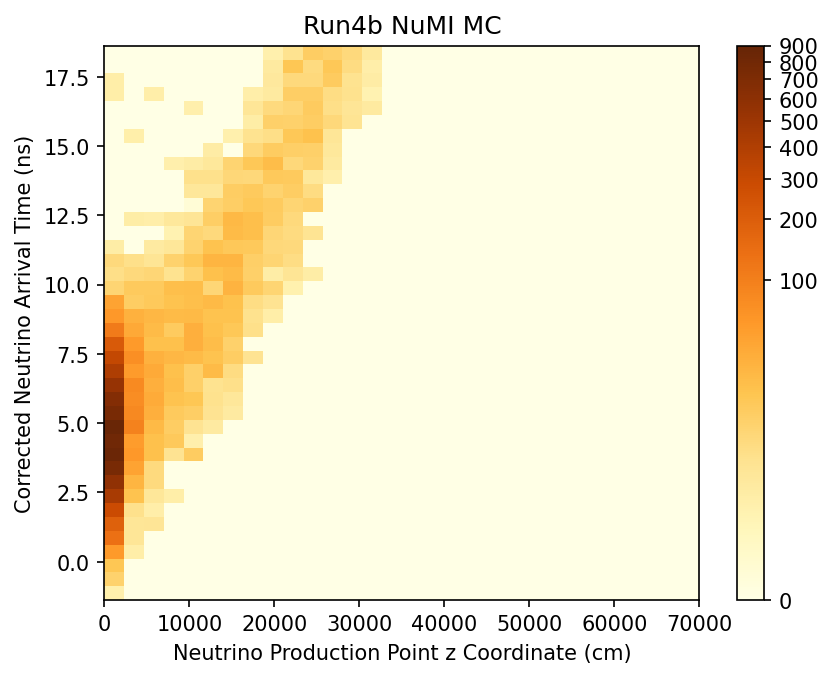

In [47]:
plt.figure()
plt.title("Run4b NuMI MC")
plt.scatter(overlay_df['mcflux_vz'],overlay_df['one_bunch_time'].to_numpy())
plt.yscale('log')
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected Neutrino Arrival Time (ns)")
plt.show()
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.scatter(overlay_df['mcflux_vz'],overlay_df['one_bunch_time'].to_numpy())
plt.axhline(y=10,color='red',ls='--')
plt.ylim(np.min(overlay_df['one_bunch_time'].to_numpy()),np.min(overlay_df['one_bunch_time'].to_numpy())+20)
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected Neutrino Arrival Time (ns)")
plt.show()
plt.show()

vz = overlay_df['mcflux_vz']
time = overlay_df['one_bunch_time'].to_numpy()
dist, x, y = np.histogram2d(vz,time,range=((0,70000),(np.min(overlay_df['one_bunch_time'].to_numpy()),np.min(overlay_df['one_bunch_time'].to_numpy())+20)),bins=(30,40),
                           weights=overlay_df['net_weight'].to_numpy())
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
c = plt.pcolormesh(x, y, dist.T,cmap='YlOrBr', norm=mpl.colors.PowerNorm(gamma=0.25,vmax=900))
plt.colorbar(c)
#plt.axhline(y=10,color='red',ls='--')
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected Neutrino Arrival Time (ns)")
plt.show()

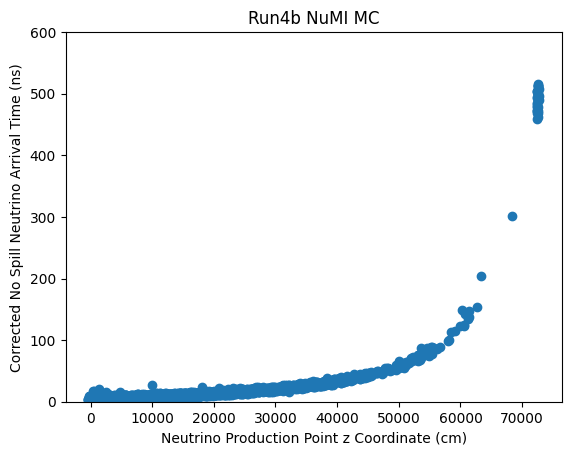

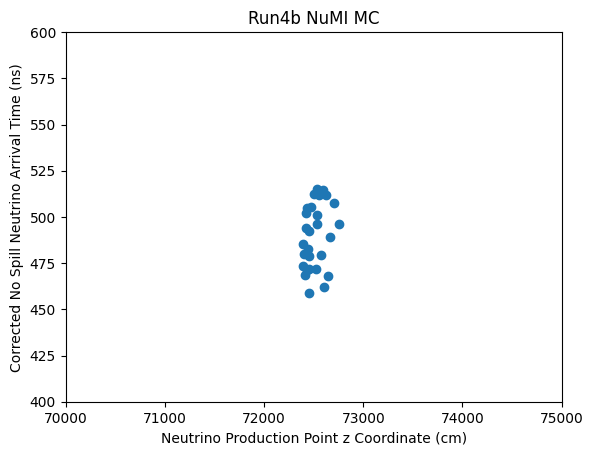

In [27]:

plt.figure()
plt.title("Run4b NuMI MC")
plt.scatter(overlay_df['mcflux_vz'],overlay_df['cor_nu_time_nospill'].to_numpy()-overlay_df['times_adjusted'].to_numpy()-2273)
plt.ylim(0,600)
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.scatter(overlay_df['mcflux_vz'],overlay_df['cor_nu_time_nospill'].to_numpy()-overlay_df['times_adjusted'].to_numpy()-2273)
plt.xlim(70000,75000)
plt.ylim(400,600)
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.show()


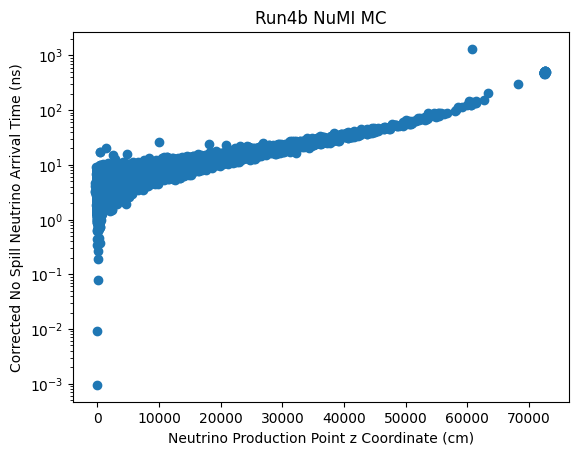

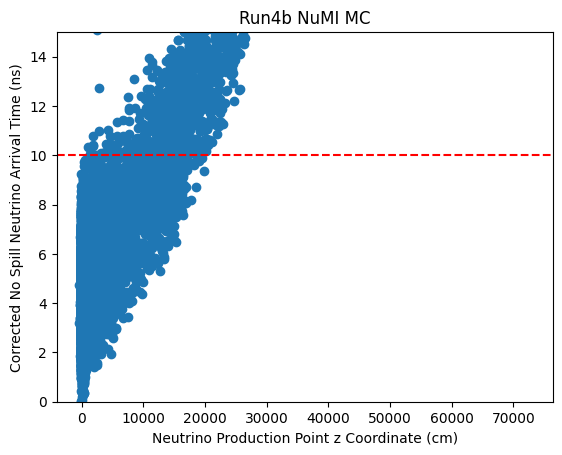

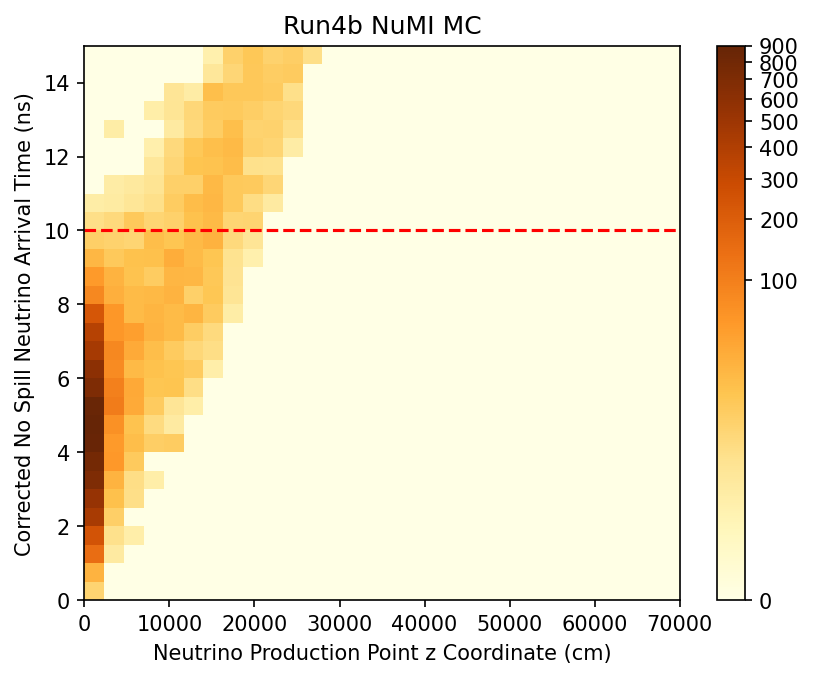

In [48]:
plt.figure()
plt.title("Run4b NuMI MC")
plt.scatter(overlay_df['mcflux_vz'],overlay_df['cor_nu_time_nospill'].to_numpy()-overlay_df['times_adjusted'].to_numpy()-2273)
plt.yscale('log')
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.show()
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.scatter(overlay_df['mcflux_vz'],overlay_df['cor_nu_time_nospill'].to_numpy()-overlay_df['times_adjusted'].to_numpy()-2273)
plt.axhline(y=10,color='red',ls='--')
plt.ylim(0,15)
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.show()
plt.show()

vz = overlay_df['mcflux_vz']
time = overlay_df['cor_nu_time_nospill'].to_numpy()-overlay_df['times_adjusted'].to_numpy()-np.ones_like(overlay_df['times_adjusted'].to_numpy())*2273
dist, x, y = np.histogram2d(vz,time,range=((0,70000),(0,15)),bins=(30,30),
                                                       weights=overlay_df['net_weight'].to_numpy())
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
c = plt.pcolormesh(x, y, dist.T,cmap='YlOrBr', norm=mpl.colors.PowerNorm(gamma=0.25,vmax=900))
plt.colorbar(c)
plt.axhline(y=10,color='red',ls='--')
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.show()

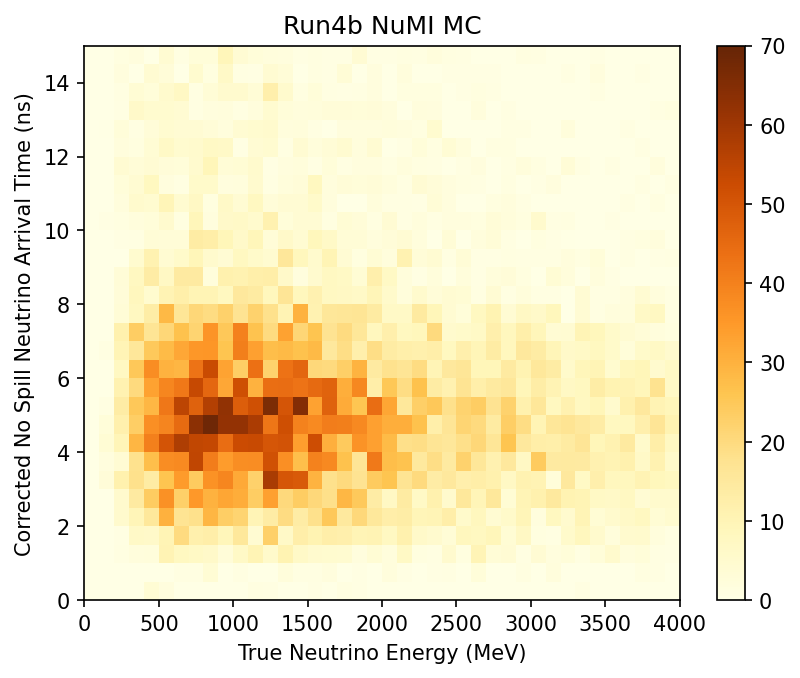

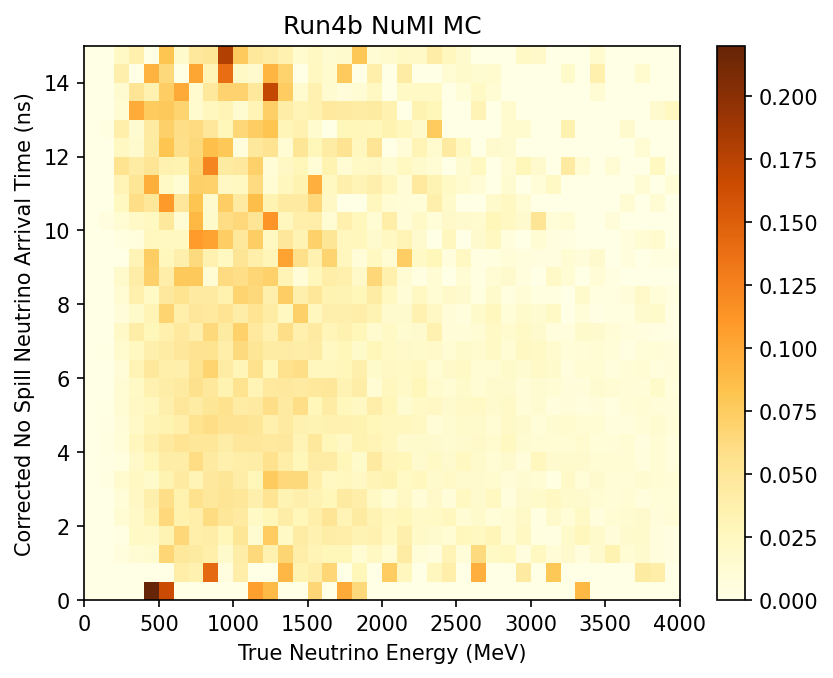

/var/folders/44/h4qhfb4d6r54v8lb5v_tptbc0000gp/T/ipykernel_41863/3744528879.py:30: RuntimeWarning: invalid value encountered in divide
  c = plt.pcolormesh(x, y, (dist).T/row_sum,cmap='YlOrBr',vmax=0.22)


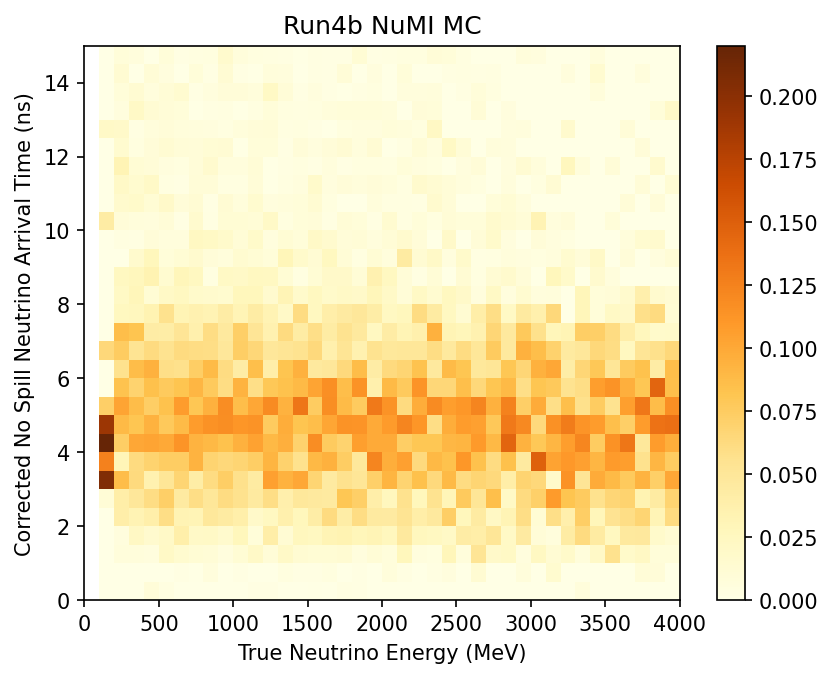

In [58]:


energy = overlay_df['truth_nuEnergy']
time = overlay_df['cor_nu_time_nospill'].to_numpy()-overlay_df['times_adjusted'].to_numpy()-np.ones_like(overlay_df['times_adjusted'].to_numpy())*2273
dist, x, y = np.histogram2d(energy,time,range=((0,4000),(0,15)),bins=(40,30),weights=overlay_df['net_weight'].to_numpy())
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
c = plt.pcolormesh(x, y, dist.T,cmap='YlOrBr',vmax=70)
plt.colorbar(c)
plt.ylabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.xlabel('True Neutrino Energy (MeV)')
plt.show()

energy = overlay_df['truth_nuEnergy']
time = overlay_df['cor_nu_time_nospill'].to_numpy()-overlay_df['times_adjusted'].to_numpy()-np.ones_like(overlay_df['times_adjusted'].to_numpy())*2273
dist, x, y = np.histogram2d(energy,time,range=((0,4000),(0,15)),bins=(40,30),weights=overlay_df['net_weight'].to_numpy())
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
col_sum = dist.sum(axis=0)
c = plt.pcolormesh(x, y, (dist/col_sum).T,cmap='YlOrBr',vmax=0.22)
plt.colorbar(c)
plt.ylabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.xlabel('True Neutrino Energy (MeV)')
plt.show()

energy = overlay_df['truth_nuEnergy']
time = overlay_df['cor_nu_time_nospill'].to_numpy()-overlay_df['times_adjusted'].to_numpy()-np.ones_like(overlay_df['times_adjusted'].to_numpy())*2273
dist, x, y = np.histogram2d(energy,time,range=((0,4000),(0,15)),bins=(40,30),weights=overlay_df['net_weight'].to_numpy())
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
row_sum = dist.sum(axis=1)
c = plt.pcolormesh(x, y, (dist).T/row_sum,cmap='YlOrBr',vmax=0.22)
plt.colorbar(c)
plt.ylabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.xlabel('True Neutrino Energy (MeV)')
plt.show()

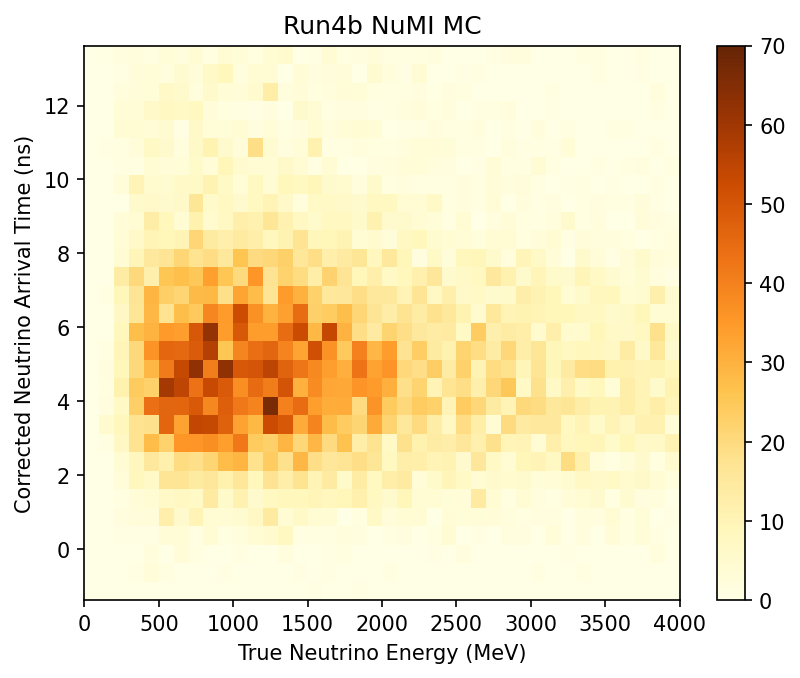

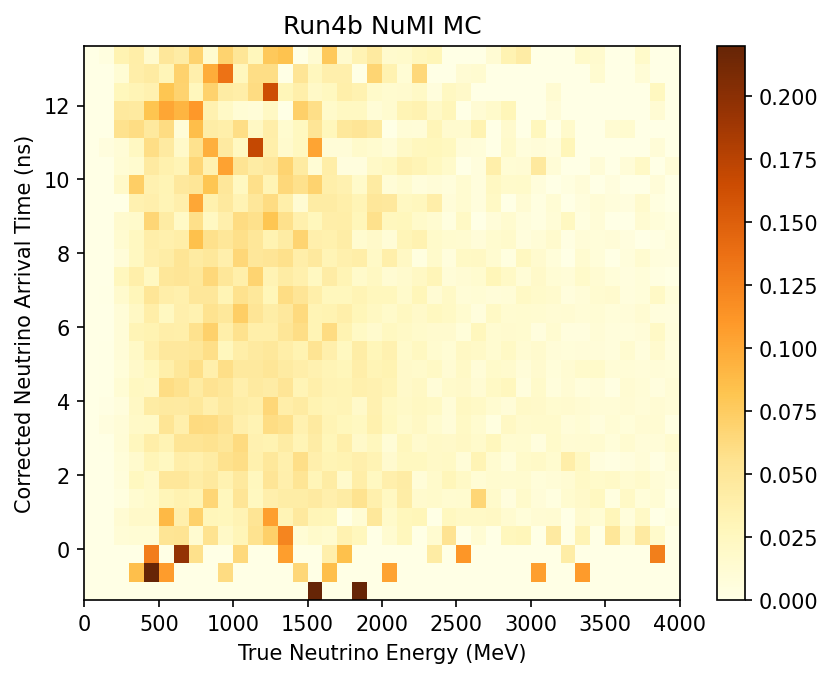

/var/folders/44/h4qhfb4d6r54v8lb5v_tptbc0000gp/T/ipykernel_41863/1068237938.py:33: RuntimeWarning: invalid value encountered in divide
  c = plt.pcolormesh(x, y, (dist).T/row_sum,cmap='YlOrBr',vmax=0.22)


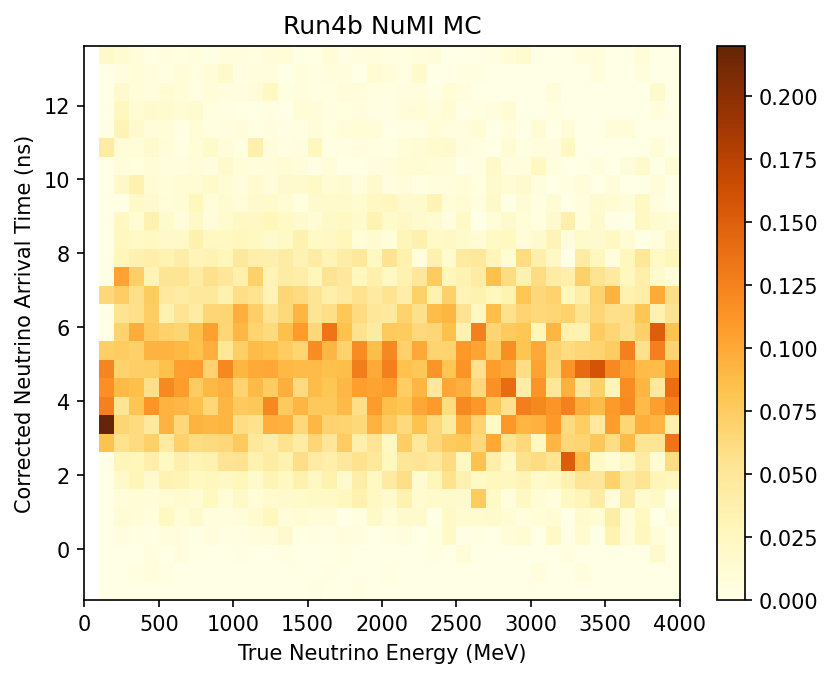

In [59]:

energy = overlay_df['truth_nuEnergy']
time = overlay_df['one_bunch_time'].to_numpy()
dist, x, y = np.histogram2d(energy,time,range=((0,4000),(np.min(overlay_df['one_bunch_time'].to_numpy()),np.min(overlay_df['one_bunch_time'].to_numpy())+15)),bins=(40,30)
                           ,weights=overlay_df['net_weight'].to_numpy())
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
c = plt.pcolormesh(x, y, dist.T,cmap='YlOrBr',vmax=70)
plt.colorbar(c)
plt.ylabel("Corrected Neutrino Arrival Time (ns)")
plt.xlabel('True Neutrino Energy (MeV)')
plt.show()

energy = overlay_df['truth_nuEnergy']
time = overlay_df['one_bunch_time'].to_numpy()
dist, x, y = np.histogram2d(energy,time,range=((0,4000),(np.min(overlay_df['one_bunch_time'].to_numpy()),np.min(overlay_df['one_bunch_time'].to_numpy())+15)),bins=(40,30)
                           ,weights=overlay_df['net_weight'].to_numpy())
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
col_sum = dist.sum(axis=0)
c = plt.pcolormesh(x, y, (dist/col_sum).T,cmap='YlOrBr',vmax=0.22)
plt.colorbar(c)
plt.ylabel("Corrected Neutrino Arrival Time (ns)")
plt.xlabel('True Neutrino Energy (MeV)')
plt.show()

energy = overlay_df['truth_nuEnergy']
time = overlay_df['one_bunch_time'].to_numpy()
dist, x, y = np.histogram2d(energy,time,range=((0,4000),(np.min(overlay_df['one_bunch_time'].to_numpy()),np.min(overlay_df['one_bunch_time'].to_numpy())+15)),bins=(40,30)
                           ,weights=overlay_df['net_weight'].to_numpy())
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
row_sum = dist.sum(axis=1)
c = plt.pcolormesh(x, y, (dist).T/row_sum,cmap='YlOrBr',vmax=0.22)
plt.colorbar(c)
plt.ylabel("Corrected Neutrino Arrival Time (ns)")
plt.xlabel('True Neutrino Energy (MeV)')
plt.show()

data: Gaussian      mean: -0.1337   std: 1.9593   C: 48.4085
315.143069712355


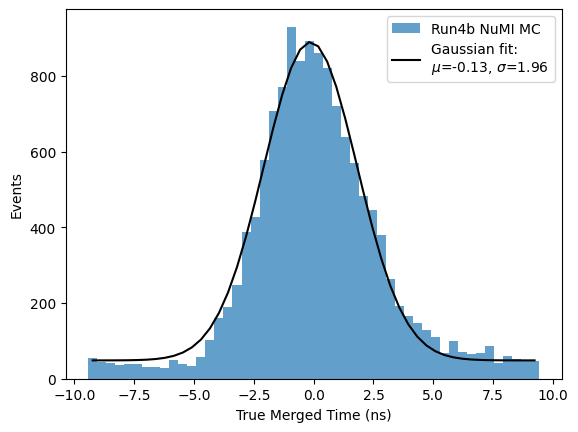

In [61]:
nbins = 50

data = overlay_df.query("merge_time_truth>-9.42 and merge_time_truth<9.42")["merge_time_truth"].to_numpy()
weights = overlay_df.query("merge_time_truth>-9.42 and merge_time_truth<9.42")["net_weight"].to_numpy()
y,xbins = np.histogram(data,bins=nbins,range=(-9.42, 9.42),weights=weights)
x = get_bin_centers(xbins)

popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

chi2=0
for i in range(len(x)):
    pred = gaus(x,*popt)[i]
    chi2 += (y[i]-pred)**2/pred
print(chi2)


plt.figure()
plt.hist(data,bins=nbins,alpha=0.7, density=False,range=(-9.42, 9.42),label="Run4b NuMI MC",weights=weights)
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.ylabel("Events")
plt.xlabel("True Merged Time (ns)")
plt.legend()
plt.show()

data: Gaussian      mean: -0.0652   std: -0.7486   C: 1.9636
104.20165041294527


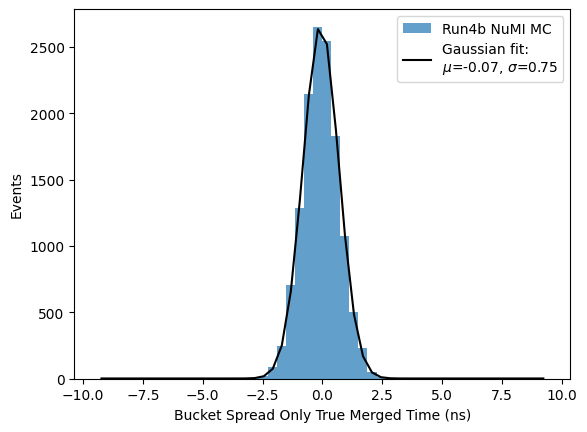

In [63]:
nbins = 50

data = overlay_df.query("merge_time_truth_spill>-9.42 and merge_time_truth_spill<9.42")["merge_time_truth_spill"].to_numpy()
weights = overlay_df.query("merge_time_truth_spill>-9.42 and merge_time_truth_spill<9.42")["net_weight"].to_numpy()
y,xbins = np.histogram(data,bins=nbins,range=(-9.42, 9.42),weights=weights)
x = get_bin_centers(xbins)

popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

chi2=0
for i in range(len(x)):
    pred = gaus(x,*popt)[i]
    chi2 += (y[i]-pred)**2/pred
print(chi2)


plt.figure()
plt.hist(data,bins=nbins,alpha=0.7, density=False,range=(-9.42, 9.42),label="Run4b NuMI MC",weights=weights)
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.ylabel("Events")
plt.legend()
plt.xlabel("Bucket Spread Only True Merged Time (ns)")
plt.show()

data: Gaussian      mean: -0.1489   std: 1.8625   C: 45.6972
377.44313650491495


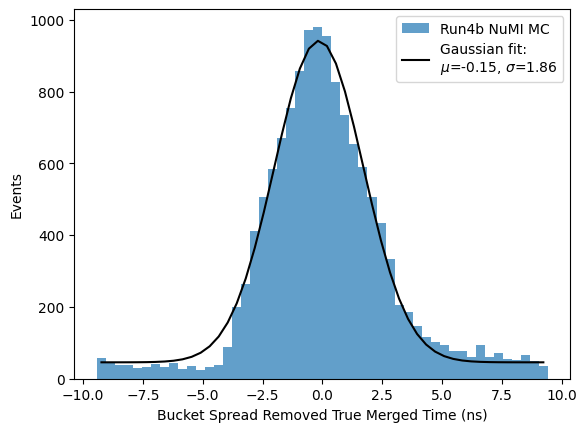

In [64]:
nbins = 50

data = overlay_df.query("merge_time_truth_nospill>-9.42 and merge_time_truth_nospill<9.42")["merge_time_truth_nospill"].to_numpy()
weights = overlay_df.query("merge_time_truth_nospill>-9.42 and merge_time_truth_nospill<9.42")["net_weight"].to_numpy()
y,xbins = np.histogram(data,bins=nbins,range=(-9.42, 9.42),weights=weights)
x = get_bin_centers(xbins)

popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

chi2=0
for i in range(len(x)):
    pred = gaus(x,*popt)[i]
    chi2 += (y[i]-pred)**2/pred
print(chi2)


plt.figure()
plt.hist(data,bins=nbins,alpha=0.7, density=False,range=(-9.42, 9.42),label="Run4b NuMI MC",weights=weights)
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.ylabel("Events")
plt.xlabel("Bucket Spread Removed True Merged Time (ns)")
plt.legend()
plt.show()

data: Gaussian      mean: -0.1719   std: 2.6135   C: 87.9619
71.56814271752964


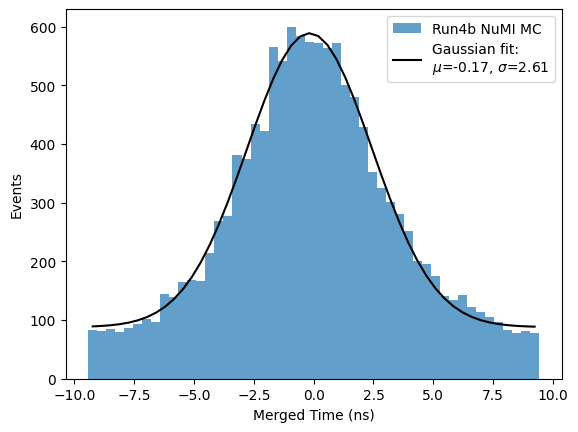

In [161]:
nbins = 50

data = overlay_df.query("merge_time>-9.42 and merge_time<9.42")["merge_time"].to_numpy()
y,xbins = np.histogram(data,bins=nbins,range=(-9.42, 9.42))
x = get_bin_centers(xbins)

popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

chi2=0
for i in range(len(x)):
    pred = gaus(x,*popt)[i]
    chi2 += (y[i]-pred)**2/pred
print(chi2)


plt.figure()
plt.hist(data,bins=nbins,alpha=0.7, density=False,range=(-9.42, 9.42),label="Run4b NuMI MC")
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.ylabel("Events")
plt.xlabel("Merged Time (ns)")
plt.legend()
plt.show()

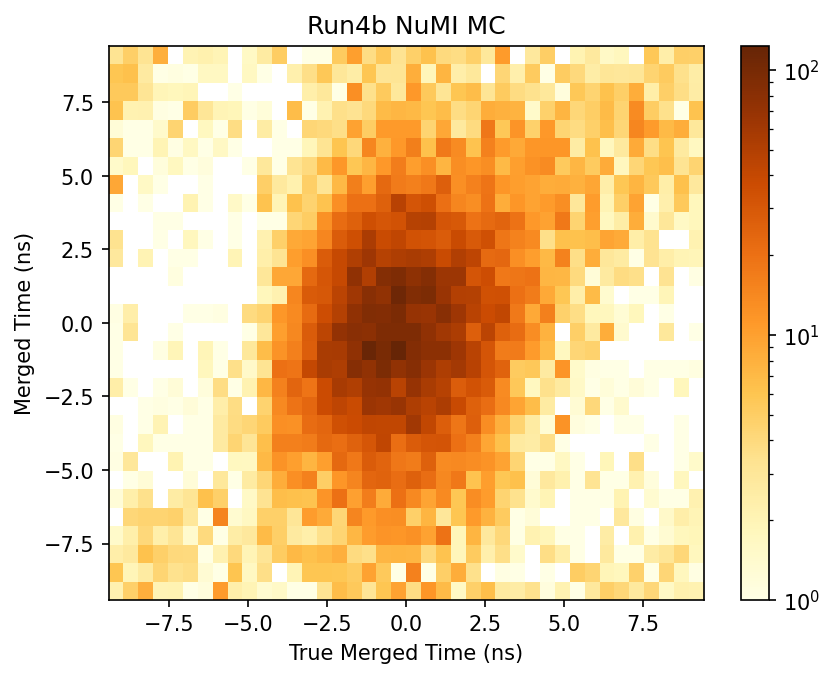

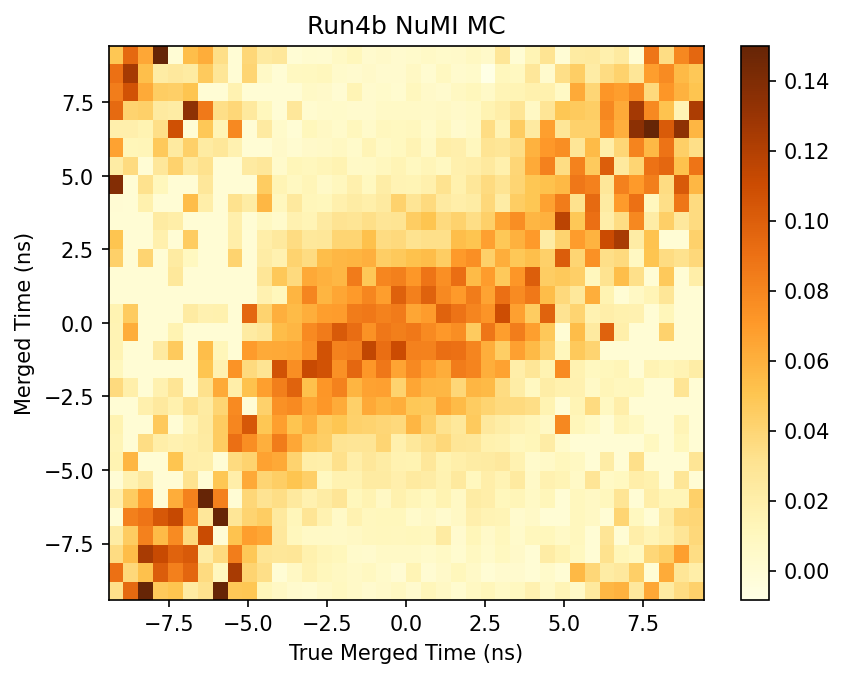

In [83]:
true_time = overlay_df['merge_time_truth'].to_numpy()
time = overlay_df['merge_time'].to_numpy()
weights = overlay_df['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(40,30),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
c = plt.pcolormesh(x, y, dist.T,cmap='YlOrBr', norm=mpl.colors.LogNorm(vmin=1))
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

true_time = overlay_df['merge_time_truth'].to_numpy()
time = overlay_df['merge_time'].to_numpy()
weights = overlay_df['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(40,30),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
row_sum = dist.sum(axis=1)
c = plt.pcolormesh(x, y, (dist).T/row_sum,cmap='YlOrBr',vmax=0.15)
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

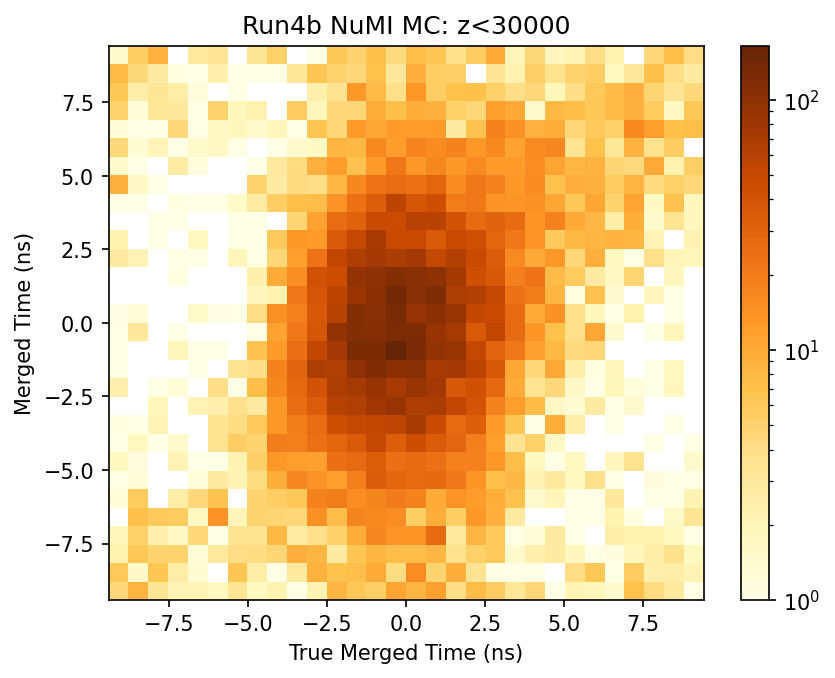

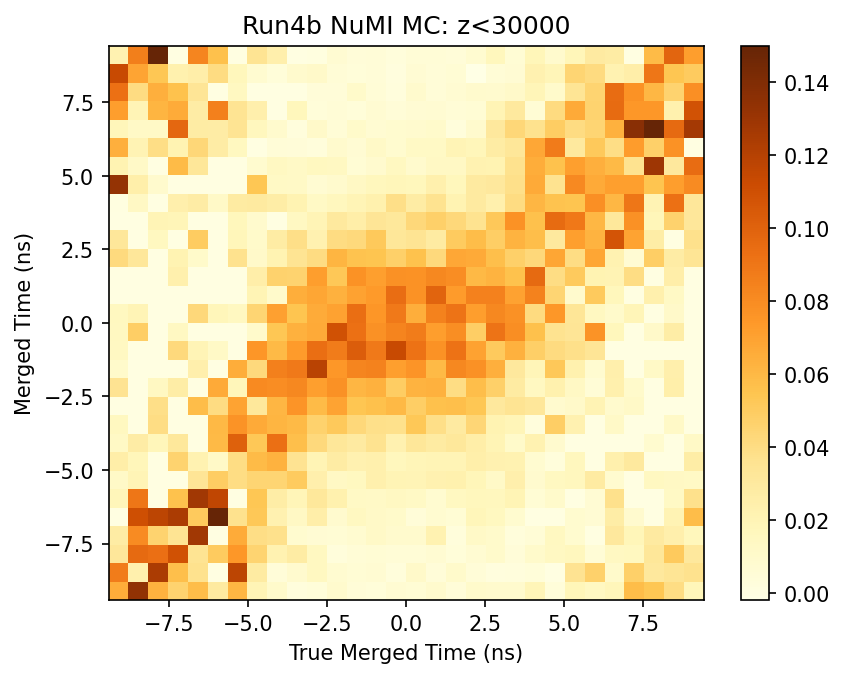

In [82]:
true_time = overlay_df.query('mcflux_vz<30000')['merge_time_truth'].to_numpy()
time = overlay_df.query('mcflux_vz<30000')['merge_time'].to_numpy()
weights = overlay_df.query('mcflux_vz<30000')['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(30,30),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC: z<30000")
c = plt.pcolormesh(x, y, dist.T,cmap='YlOrBr', norm=mpl.colors.LogNorm(vmin=1))
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

true_time = overlay_df.query('mcflux_vz<30000')['merge_time_truth'].to_numpy()
time = overlay_df.query('mcflux_vz<30000')['merge_time'].to_numpy()
weights = overlay_df.query('mcflux_vz<30000')['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(30,30),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC: z<30000")
row_sum = dist.sum(axis=1)
c = plt.pcolormesh(x, y, (dist).T/row_sum,cmap='YlOrBr',vmax=0.15)
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

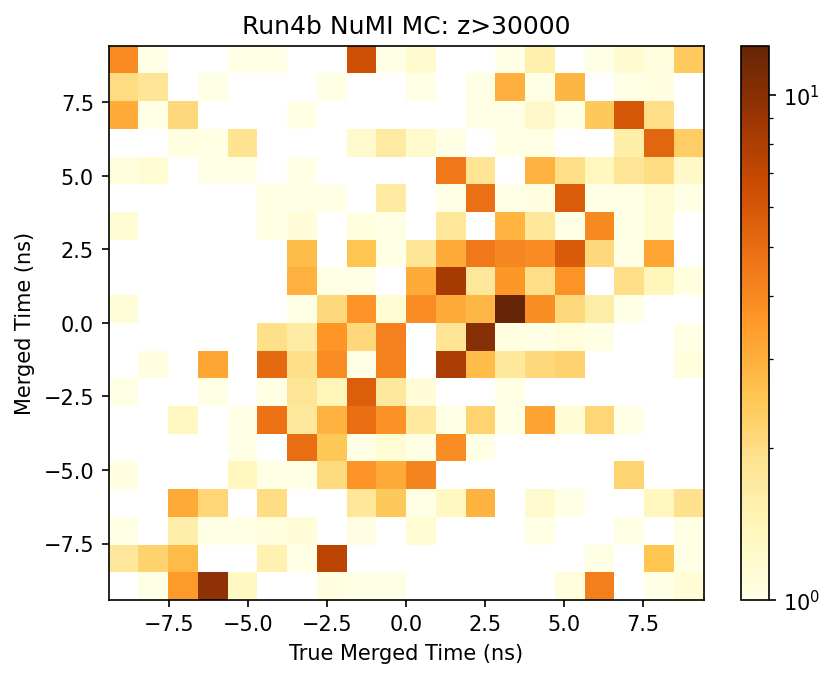

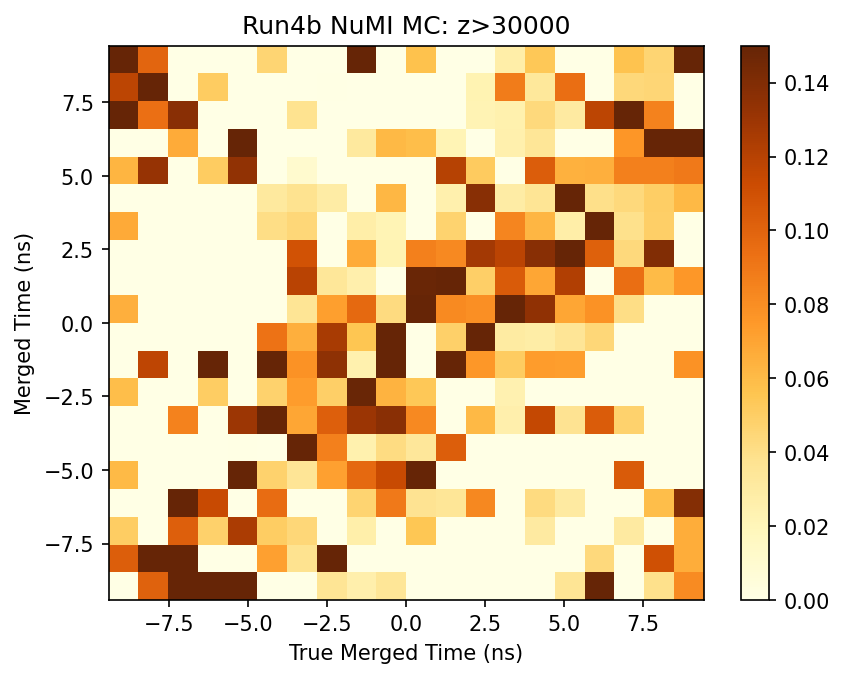

In [84]:
true_time = overlay_df.query('mcflux_vz>30000')['merge_time_truth'].to_numpy()
time = overlay_df.query('mcflux_vz>30000')['merge_time'].to_numpy()
weights = overlay_df.query('mcflux_vz>30000')['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(20,20),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC: z>30000")
c = plt.pcolormesh(x, y, dist.T,cmap='YlOrBr', norm=mpl.colors.LogNorm(vmin=1))
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

true_time = overlay_df.query('mcflux_vz>30000')['merge_time_truth'].to_numpy()
time = overlay_df.query('mcflux_vz>30000')['merge_time'].to_numpy()
weights = overlay_df.query('mcflux_vz>30000')['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(20,20),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC: z>30000")
row_sum = dist.sum(axis=1)
c = plt.pcolormesh(x, y, (dist).T/row_sum,cmap='YlOrBr',vmax=0.15)
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

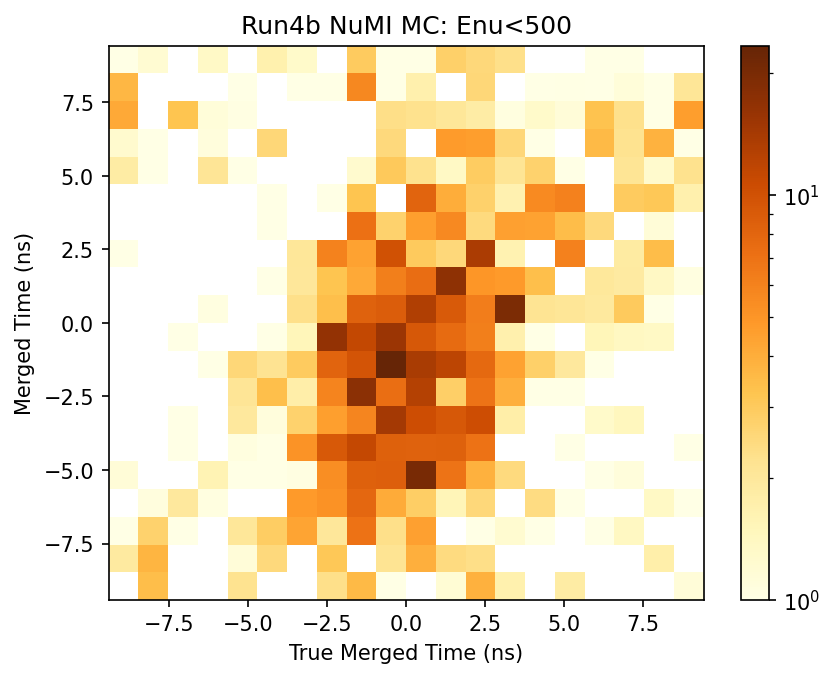

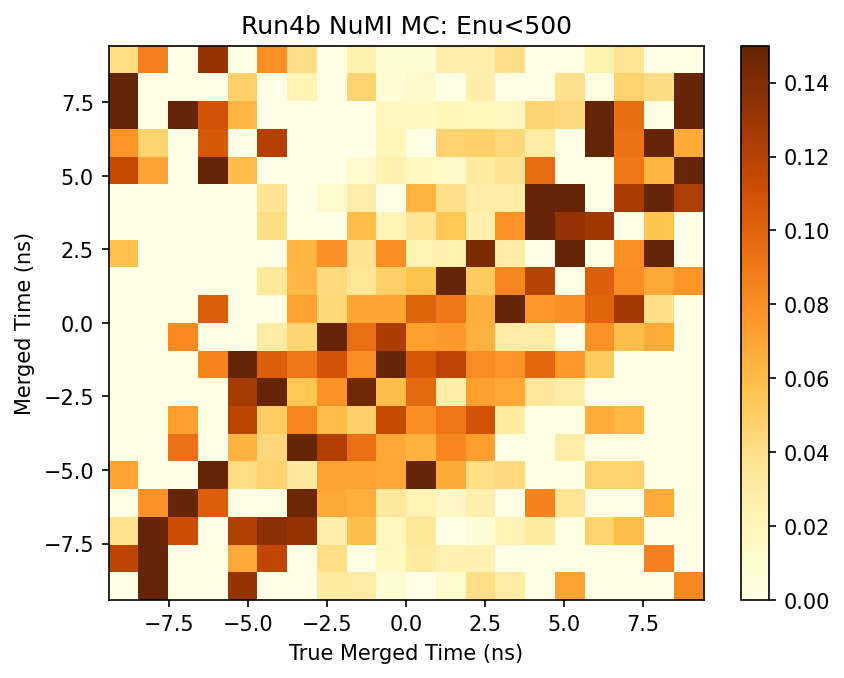

In [86]:
true_time = overlay_df.query('truth_nuEnergy<500')['merge_time_truth'].to_numpy()
time = overlay_df.query('truth_nuEnergy<500')['merge_time'].to_numpy()
weights = overlay_df.query('truth_nuEnergy<500')['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(20,20),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC: Enu<500")
c = plt.pcolormesh(x, y, dist.T,cmap='YlOrBr', norm=mpl.colors.LogNorm(vmin=1))
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

true_time = overlay_df.query('truth_nuEnergy<500')['merge_time_truth'].to_numpy()
time = overlay_df.query('truth_nuEnergy<500')['merge_time'].to_numpy()
weights = overlay_df.query('truth_nuEnergy<500')['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(20,20),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC: Enu<500")
row_sum = dist.sum(axis=1)
c = plt.pcolormesh(x, y, (dist).T/row_sum,cmap='YlOrBr',vmax=0.15)
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

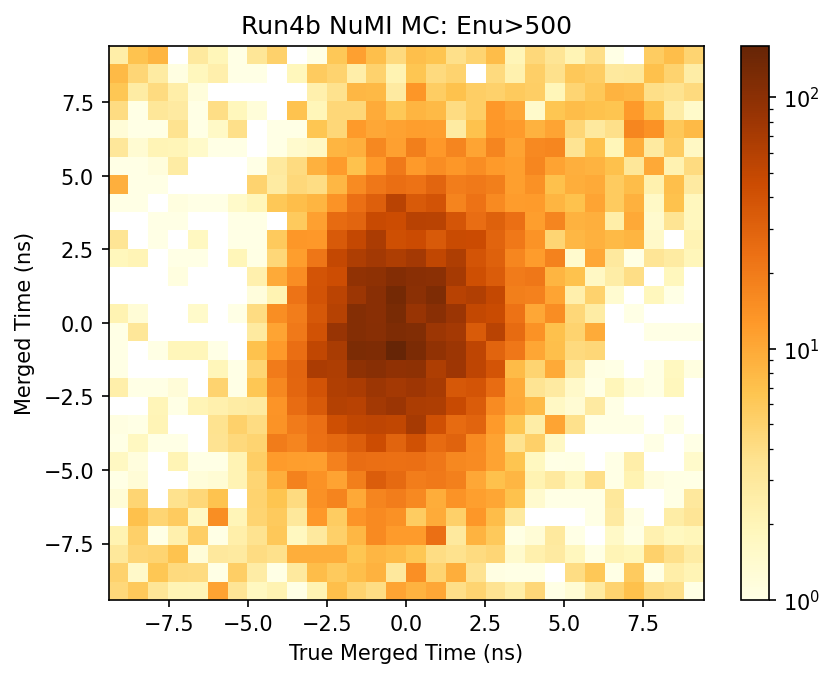

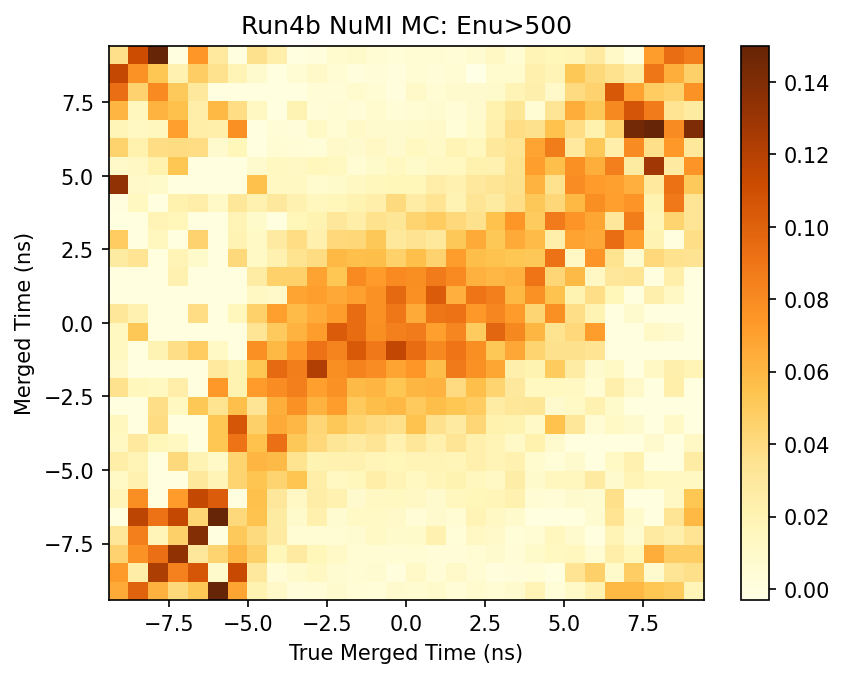

In [88]:
true_time = overlay_df.query('truth_nuEnergy>500')['merge_time_truth'].to_numpy()
time = overlay_df.query('truth_nuEnergy>500')['merge_time'].to_numpy()
weights = overlay_df.query('truth_nuEnergy>500')['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(30,30),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC: Enu>500")
c = plt.pcolormesh(x, y, dist.T,cmap='YlOrBr', norm=mpl.colors.LogNorm(vmin=1))
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

true_time = overlay_df.query('truth_nuEnergy>500')['merge_time_truth'].to_numpy()
time = overlay_df.query('truth_nuEnergy>500')['merge_time'].to_numpy()
weights = overlay_df.query('truth_nuEnergy>500')['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(30,30),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC: Enu>500")
row_sum = dist.sum(axis=1)
c = plt.pcolormesh(x, y, (dist).T/row_sum,cmap='YlOrBr',vmax=0.15)
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

mean: -76.10761310727139
median: 0.011954392211919185
std: 1129.8179330720354
q1: -3.594223849829359
q3: 3.6398084649412312
IQR: 3.617016157385295
FWHM: 2.557667430694422
data: Gaussian      mean: 0.0551   std: -3.2223
data: Gaussian      mean: 0.0531   std: -3.1474   C: 9.0455


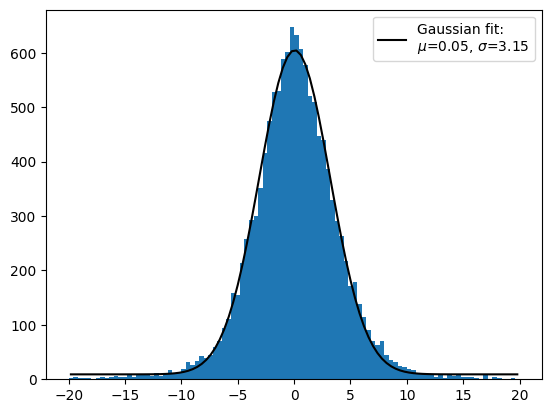

In [132]:
true_time = overlay_df.query("evtTimeNS_cor>0")['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0")["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0")['evtTimeNS_cor'].to_numpy()
offset = 5751
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=100,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.figure()
plt.hist(true_time-time+offset,bins=100,range=(-20,20))
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.legend()
plt.show()


mean: 0.19594458528467545
median: 0.1606426454202392
std: 4.228587344220187
q1: -3.3214349912985197
q3: 3.7498439634866334
IQR: 3.535639477392577
FWHM: 2.5046586669603976
data: Gaussian      mean: 0.1635   std: 3.2603
data: Gaussian      mean: 0.1606   std: 3.157   C: 12.2714


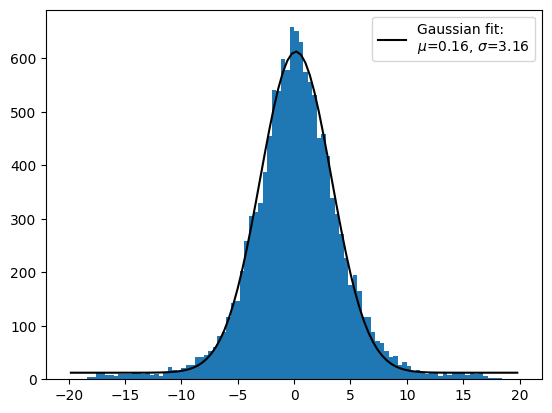

In [133]:
true_time = overlay_df.query("evtTimeNS_cor>0")['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0")['merge_time'].to_numpy()
offset = 0
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=100,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.figure()
plt.hist(true_time-time+offset,bins=100,range=(-20,20))
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.legend()
plt.show()

mean: -80.49538458844563
median: -0.043935515868724906
std: 1116.5320287001643
q1: -3.6254242805908508
q3: 3.53813225800448
IQR: 3.5817782692976654
FWHM: 2.53288773386374
data: Gaussian      mean: -0.0164   std: 3.1969
data: Gaussian      mean: -0.0186   std: 3.1225   C: 7.771


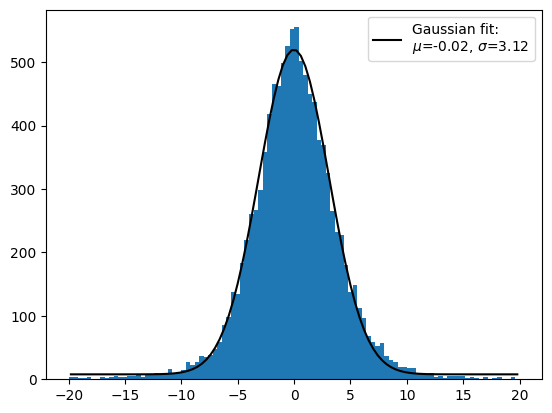

In [134]:
true_time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz<10000')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz<10000')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz<10000')['evtTimeNS_cor'].to_numpy()
offset = 5751
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=100,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.figure()
plt.hist(true_time-time+offset,bins=100,range=(-20,20))
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.legend()
plt.show()

mean: 0.15746574387436643
median: 0.11321946091266
std: 3.6473961241230213
q1: -3.284753799203172
q3: 3.600313648089068
IQR: 3.44253372364612
FWHM: 2.4367943022543
data: Gaussian      mean: 0.0979   std: -3.3004
data: Gaussian      mean: 0.0965   std: -3.2436   C: 5.7327


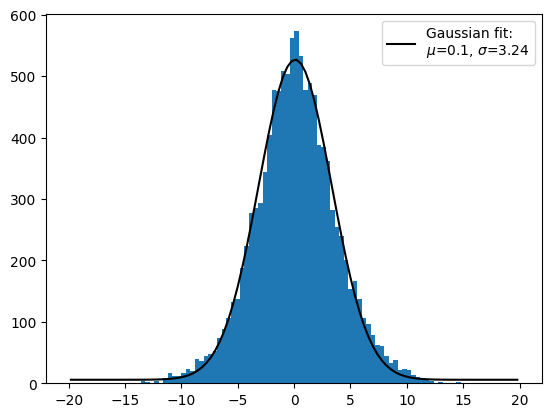

In [135]:
true_time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz<10000')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz<10000')['merge_time'].to_numpy()
offset = 0
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=100,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.figure()
plt.hist(true_time-time+offset,bins=100,range=(-20,20))
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.legend()
plt.show()

mean: -54.95666809641261
median: 0.8317894781503128
std: 1286.9302443309705
q1: -3.2843710987448875
q3: 4.840672125549027
IQR: 4.062521612146957
FWHM: 2.924858976999491
data: Gaussian      mean: 0.8714   std: 3.6197
data: Gaussian      mean: 0.874   std: 3.5381   C: 0.2728


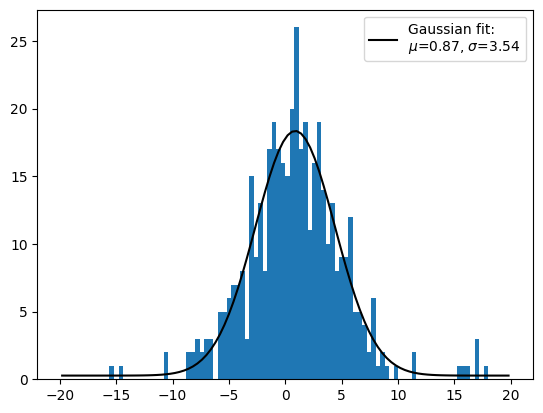

In [136]:
true_time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>30000')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>30000')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>30000')['evtTimeNS_cor'].to_numpy()
offset = 5751
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=100,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.figure()
plt.hist(true_time-time+offset,bins=100,range=(-20,20))
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.legend()
plt.show()

mean: 0.46303529341778826
median: 0.7428011892743598
std: 5.96377874548499
q1: -3.841458294012955
q3: 4.9457568713108415
IQR: 4.3936075826618985
FWHM: 3.1311863907614685
data: Gaussian      mean: 0.8803   std: 3.516
data: Gaussian      mean: 0.8745   std: 3.229   C: 0.9771


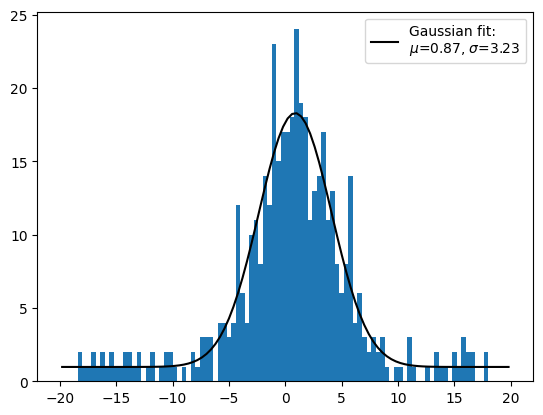

In [137]:
true_time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>30000')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>30000')['merge_time'].to_numpy()
offset = 0
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=100,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.figure()
plt.hist(true_time-time+offset,bins=100,range=(-20,20))
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.legend()
plt.show()

mean: -113.66166743408849
median: 1.0431279621279828
std: 1507.7158479702325
q1: -3.5410384349121156
q3: 5.2914722597161
IQR: 4.416255347314108
FWHM: 3.1834977569047327
data <500: Gaussian      mean: 1.363   std: 3.6917
data <500: Gaussian      mean: 1.3633   std: 3.6026   C: 1.5641
mean: -104.84740595815765
median: 0.5415862415775337
std: 1290.711614005944
q1: -3.4357661681156606
q3: 4.300636633681641
IQR: 3.868201400898651
FWHM: 2.752270181910414
data 500-800: Gaussian      mean: 0.7438   std: 3.2562
data 500-800: Gaussian      mean: 0.7411   std: -3.1232   C: 4.7013
mean: -106.98924904656815
median: 0.3467547600703256
std: 1221.5605193391623
q1: -3.146798304141193
q3: 3.873550908270117
IQR: 3.510174606205655
FWHM: 2.4953324530964878
data 500-800: Gaussian      mean: 0.4243   std: 3.0788
data 500-800: Gaussian      mean: 0.423   std: -2.9969   C: 4.5774
mean: -65.30533660429683
median: -0.06726365039048687
std: 1115.1352551435793
q1: -3.5368866836818054
q3: 3.3793701593294827
IQR: 3.

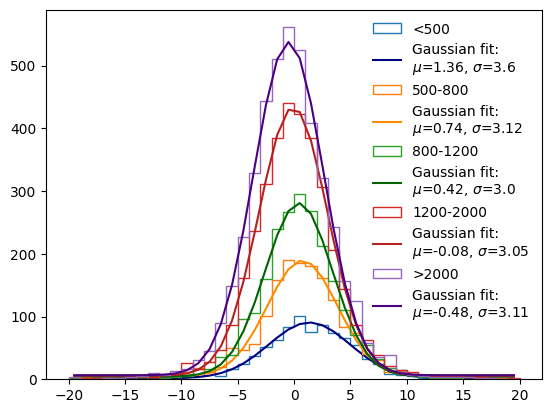

In [156]:
plt.figure()

true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')['evtTimeNS_cor'].to_numpy()
offset = 5751
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='<500',histtype='step')
plt.plot(x,gaus(x,*popt),color='navy',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='500-800',histtype='step')
plt.plot(x,gaus(x,*popt),color='darkorange',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='800-1200',histtype='step')
plt.plot(x,gaus(x,*popt),color='darkgreen',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")



true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='1200-2000',histtype='step')
plt.plot(x,gaus(x,*popt),color='firebrick',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='>2000',histtype='step')
plt.plot(x,gaus(x,*popt),color='indigo',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


plt.legend(frameon=False)
plt.show()

mean: 0.839751564728515
median: 1.0962550193821698
std: 5.050094846026479
q1: -3.064835777209009
q3: 5.201134321446078
IQR: 4.1329850493275435
FWHM: 3.018485405422093
data <500: Gaussian      mean: 1.3779   std: 3.7172
data <500: Gaussian      mean: 1.3817   std: 3.5474   C: 2.993
mean: 0.6001651277623092
median: 0.6825469886807696
std: 4.7046588779711
q1: -3.0422784739744206
q3: 4.4057213794443655
IQR: 3.723999926709393
FWHM: 2.6770244295906833
data 500-800: Gaussian      mean: 0.8402   std: 3.3086
data 500-800: Gaussian      mean: 0.8394   std: -3.1227   C: 6.2479
mean: 0.53787680990489
median: 0.4854946072430266
std: 4.3070551907806145
q1: -2.8858953706057213
q3: 3.9786356540320775
IQR: 3.4322655123188994
FWHM: 2.457536050479158
data 500-800: Gaussian      mean: 0.5111   std: -3.086
data 500-800: Gaussian      mean: 0.5087   std: 2.9644   C: 6.8725
mean: 0.10345243443961685
median: 0.07654905331901318
std: 4.066839453486944
q1: -3.3093404963371356
q3: 3.4288422447958147
IQR: 3.36909

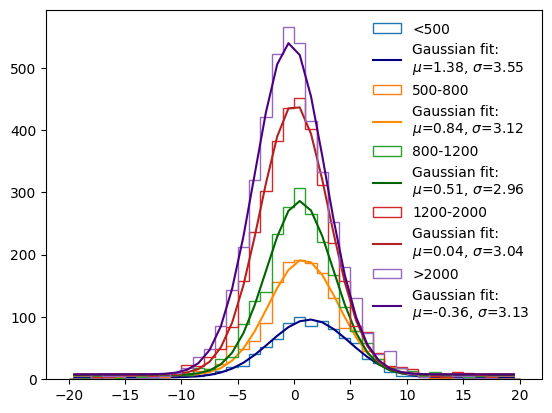

In [157]:
plt.figure()

true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')['merge_time'].to_numpy()
offset = 0
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='<500',histtype='step')
plt.plot(x,gaus(x,*popt),color='navy',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='500-800',histtype='step')
plt.plot(x,gaus(x,*popt),color='darkorange',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='800-1200',histtype='step')
plt.plot(x,gaus(x,*popt),color='darkgreen',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")



true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='1200-2000',histtype='step')
plt.plot(x,gaus(x,*popt),color='firebrick',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='>2000',histtype='step')
plt.plot(x,gaus(x,*popt),color='indigo',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


plt.legend(frameon=False)
plt.show()

mean: -113.66166743408849
median: 1.0431279621279828
std: 1507.7158479702325
q1: -3.5410384349121156
q3: 5.2914722597161
IQR: 4.416255347314108
FWHM: 3.1834977569047327
data <500: Gaussian      mean: 1.363   std: 3.6917
data <500: Gaussian      mean: 1.3633   std: 3.6026   C: 0.0018
mean: -104.84740595815765
median: 0.5415862415775337
std: 1290.711614005944
q1: -3.4357661681156606
q3: 4.300636633681641
IQR: 3.868201400898651
FWHM: 2.752270181910414
data 500-800: Gaussian      mean: 0.7438   std: 3.2562
data 500-800: Gaussian      mean: 0.7411   std: 3.1232   C: 0.0029
mean: -106.98924904656815
median: 0.3467547600703256
std: 1221.5605193391623
q1: -3.146798304141193
q3: 3.873550908270117
IQR: 3.510174606205655
FWHM: 2.4953324530964878
data 500-800: Gaussian      mean: 0.4243   std: 3.0788
data 500-800: Gaussian      mean: 0.423   std: 2.9969   C: 0.002
mean: -65.30533660429683
median: -0.06726365039048687
std: 1115.1352551435793
q1: -3.5368866836818054
q3: 3.3793701593294827
IQR: 3.458

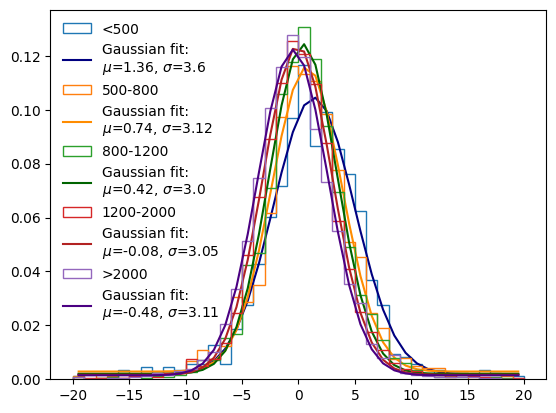

In [159]:
plt.figure()

true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')['evtTimeNS_cor'].to_numpy()
offset = 5751
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='<500',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='navy',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='500-800',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='darkorange',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='800-1200',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='darkgreen',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")



true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='1200-2000',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='firebrick',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='>2000',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='indigo',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


plt.legend(frameon=False)
plt.show()

mean: 0.839751564728515
median: 1.0962550193821698
std: 5.050094846026479
q1: -3.064835777209009
q3: 5.201134321446078
IQR: 4.1329850493275435
FWHM: 3.018485405422093
data <500: Gaussian      mean: 1.3779   std: 3.7172
data <500: Gaussian      mean: 1.3817   std: 3.5474   C: 0.0032
mean: 0.6001651277623092
median: 0.6825469886807696
std: 4.7046588779711
q1: -3.0422784739744206
q3: 4.4057213794443655
IQR: 3.723999926709393
FWHM: 2.6770244295906833
data 500-800: Gaussian      mean: 0.8402   std: 3.3086
data 500-800: Gaussian      mean: 0.8394   std: 3.1227   C: 0.0037
mean: 0.53787680990489
median: 0.4854946072430266
std: 4.3070551907806145
q1: -2.8858953706057213
q3: 3.9786356540320775
IQR: 3.4322655123188994
FWHM: 2.457536050479158
data 500-800: Gaussian      mean: 0.5111   std: 3.086
data 500-800: Gaussian      mean: 0.5087   std: 2.9644   C: 0.0029
mean: 0.10345243443961685
median: 0.07654905331901318
std: 4.066839453486944
q1: -3.3093404963371356
q3: 3.4288422447958147
IQR: 3.369091

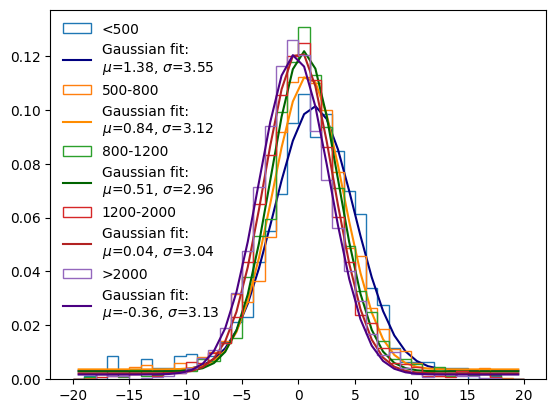

In [89]:
plt.figure()

true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')['merge_time'].to_numpy()
offset = 0
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='<500',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='navy',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='500-800',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='darkorange',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='800-1200',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='darkgreen',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")



true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='1200-2000',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='firebrick',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='>2000',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='indigo',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


plt.legend(frameon=False)
plt.show()

mean: -76.10761310727139
median: 0.011954392211919185
std: 1129.8179330720354
q1: -3.594223849829359
q3: 3.6398084649412312
IQR: 3.617016157385295
FWHM: 2.557667430694422
data: Gaussian      mean: 0.0541   std: 3.2212
data: Gaussian      mean: 0.052   std: 3.1465   C: 4.518
data: Gaussian     mean1: 0.0453  std1: 2.5957    mean2: 0.0453  std2: 4.5998   a1: 209.3092   a2: 99.4472


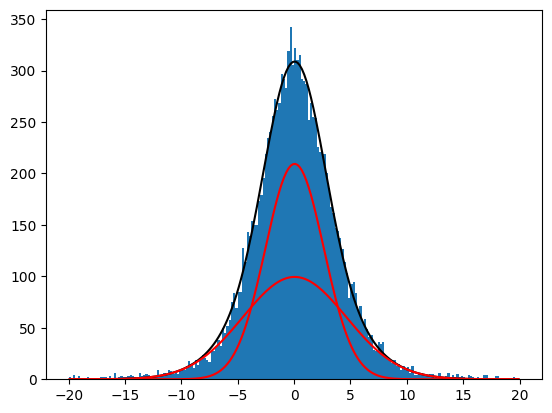

In [207]:
true_time = overlay_df.query("evtTimeNS_cor>0")['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0")["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0")['evtTimeNS_cor'].to_numpy()
offset = 5751
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=200,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))
popt,pcov = curve_fit(gaus_sum,x,y,p0=(popt[0]*0.2,popt[1],popt[2],popt[0]*0.5,popt[2]*2))
print("data: Gaussian     mean1:",round(popt[1],4)," std1:",round(popt[2],4),"   mean2:",round(popt[1],4)," std2:",round(popt[4],4),"  a1:",round(popt[0],4),"  a2:",round(popt[3],4))

plt.figure()
plt.hist(true_time-time+offset,bins=200,range=(-20,20))
plt.plot(x,gaus_sum(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.plot(x,gaus_noC(x,*[popt[0],popt[1],popt[2]]),color='red',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.plot(x,gaus_noC(x,*[popt[3],popt[1],popt[4]]),color='red',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


